# 1. CONFIGURAÇÃO DO AMBIENTE E BIBLIOTECAS

In [34]:
# Pandas: Biblioteca padrão para manipulação de dados em tabelas (DataFrames)
import pandas as pd

# NumPy: Biblioteca para computação numérica de alto desempenho e vetorização de matrizes
import numpy as np

# Matplotlib.pyplot: Módulo essencial para plotagem de gráficos e exportação de figuras
import matplotlib.pyplot as plt

# Seaborn: Biblioteca de visualização estatística baseada no Matplotlib
import seaborn as sns

# SHAP: Biblioteca de IA Explicável baseada em Valores de Shapley (Teoria dos Jogos Cooperativos)
import shap

# Gzip: Utilitário para abrir e descompactar os arquivos compactados dos modelos (.gz)
import gzip

# Pickle: Biblioteca para ler e desserializar objetos Python salvos em disco
import pickle

# Copy: Permite realizar cópias profundas em memória, evitando mutações acidentais de objetos
import copy

# OS: Interface com o sistema operacional para gerenciamento de arquivos
import os

# Pathlib.Path: Abordagem orientada a objetos para gerenciar caminhos de diretórios de forma limpa
from pathlib import Path

# Datetime: Módulo para captura de carimbos de tempo (timestamps) e gerenciamento de datas
from datetime import datetime

# Importação de métricas oficiais do Scikit-Learn para validação do desempenho dos modelos
from sklearn.metrics import (
    confusion_matrix,        # Gera a matriz de confusão (TP, FP, TN, FN)
    ConfusionMatrixDisplay, # Plota graficamente a matriz de confusão
    accuracy_score,         # Calcula a taxa de acerto global do classificador
    precision_score,        # Calcula a precisão (relevante para monitorar Falsos Positivos)
    recall_score,           # Calcula o recall (relevante para monitorar Falsos Negativos)
    f1_score,               # Média harmônica balanceada entre precisão e recall
    classification_report   # Tabela textual com o resumo completo de métricas por classe
)

# Warnings: Desativa alertas de depreciação do ecossistema Python para manter o console limpo
import warnings
warnings.filterwarnings("ignore")

# RANDOM_STATE: Semente estável compartilhada para garantir reprodutibilidade matemática exata
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas carregadas e semente de reprodutibilidade configurada com sucesso.")

Bibliotecas carregadas e semente de reprodutibilidade configurada com sucesso.


# 2. DIRETÓRIOS E CARREGAMENTO DOS DADOS DE REDE

In [36]:
# Correção para manter compatibilidade com parâmetros legados de estratégias de amostragem
def get_sampling_strategy(*args, **kwargs):
    return "auto"

# PROJECT_ROOT: Sobe um nível em relação ao diretório de execução para mapear a raiz real do projeto
PROJECT_ROOT = Path.cwd().parent

# Definição dos caminhos absolutos dos subdiretórios de dados, resultados e relatórios do projeto
DATASET_DIR = PROJECT_ROOT / "datasense" / "dataset"
RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
EVAL_DIR = PROJECT_ROOT / "experiments" / "evaluations"
XAI_DIR = PROJECT_ROOT / "experiments" / "results_xai"

# Criação dinâmica e recursiva das pastas de saída do SHAP, prevenindo erros de FileNotFoundError
SHAP_GLOBAL_DIR = XAI_DIR / "shap_global"
SHAP_MICRO_DIR = XAI_DIR / "shap_micro"
FPFN_BINARY_DIR = XAI_DIR / "fpfn_binary"
FPFN_MULTI_DIR = XAI_DIR / "fpfn_multiclass"
FIG_DIR = XAI_DIR / "figures"

for path in [SHAP_GLOBAL_DIR, SHAP_MICRO_DIR, FPFN_BINARY_DIR, FPFN_MULTI_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True) # Cria a pasta e seus pais se não existirem

# Carrega o conjunto de teste benchmark no formato otimizado Parquet
print("\nCarregando dataset de teste Parquet...")
dataset = pd.read_parquet(DATASET_DIR / "datasense_full_test_1sec.parquet")

# Extração e cópia profunda dos alvos reais do problema de segurança
y_test_binary = dataset["label1"].copy() # Destino binário: Benigno vs Ataque
y_test_multi = dataset["label4"].copy()  # Destino multiclasse: 8 classes de ameaças

# Identifica dinamicamente todas as colunas que carregam prefixo de rótulo (labels)
label_cols = [col for col in dataset.columns if col.startswith("label") or "extended" in col.lower()]

# Remove as colunas de rótulo para isolar estritamente o conjunto de features de tráfego (X_test)
X_test = dataset.drop(columns=label_cols, errors="ignore")
print(f"Dataset de features carregado com sucesso. Dimensões atuais: {X_test.shape}")


Carregando dataset de teste Parquet...
Dataset de features carregado com sucesso. Dimensões atuais: (56798, 106)


In [21]:

# OBJETIVO:
#
# Carregar:
#
# 1) Dataset de teste
# 2) Modelos treinados
# 3) Resultados do evaluations
#
# JUSTIFICATIVA:
#
# O dataset é usado para SHAP
#
# Os modelos são necessários
# para calcular explicabilidade
#
# O evaluations fornece:
#
# métricas
# confusion matrices
# PCA
# t-SNE
#



PROJECT_ROOT=Path.cwd().parent


# ------------------------------------------------
# Caminhos reais do projeto
# ------------------------------------------------

DATASET_DIR=PROJECT_ROOT/"datasense"/"dataset"

RESULTS_DIR=PROJECT_ROOT/"experiments"/"results"

EVAL_DIR=PROJECT_ROOT/"experiments"/"evaluations"


print("="*60)

print("VERIFICAÇÃO")

print("="*60)

print("\nDataset:",DATASET_DIR.exists())

print("Results:",RESULTS_DIR.exists())

print("Evaluations:",EVAL_DIR.exists())


# ------------------------------------------------
# Carregar Dataset
# ------------------------------------------------

X_test=pd.read_parquet(

DATASET_DIR/
"datasense_full_test_1sec.parquet"

)


y_test=X_test["label4"].copy()


X_test=X_test.drop(

columns=[

"label1",
"label2",
"label4"

],

errors="ignore"

)

print("\nDataset:")

print(X_test.shape)



# ------------------------------------------------
# Carregar modelos
# ------------------------------------------------

MODELS={}


MODEL_PATHS={

"logistic_regression":

RESULTS_DIR/
"logistic_regression_full_all"/
"pipe.pickle.gz",


"decision_tree":

RESULTS_DIR/
"decision_tree_full_all"/
"pipe.pickle.gz",


"random_forest":

RESULTS_DIR/
"random_forest_full_all"/
"pipe.pickle.gz"

}



for name,path in MODEL_PATHS.items():

    print("\nCarregando:",name)

    with gzip.open(

    path,
    "rb"

    ) as f:

        MODELS[name]=pickle.load(
        f
        )


print("\nModelos carregados:")

print(MODELS.keys())


# ------------------------------------------------
# Carregar Feature Importance
# ------------------------------------------------

feature_importance=pd.read_csv(

EVAL_DIR/
"feature_importances.csv"

)

print("\nFeature importance carregado")

display(

feature_importance.head()

)

VERIFICAÇÃO

Dataset: True
Results: True
Evaluations: True

Dataset:
(56798, 108)

Carregando: logistic_regression

Carregando: decision_tree

Carregando: random_forest

Modelos carregados:
dict_keys(['logistic_regression', 'decision_tree', 'random_forest'])

Feature importance carregado


,feature,binary_decision_tree_importance,binary_logistic_regression_importance,binary_random_forest_importance,binary_avg_importance,grouped_decision_tree_importance,grouped_logistic_regression_importance,grouped_random_forest_importance,grouped_avg_importance,all_decision_tree_importance,all_logistic_regression_importance,all_random_forest_importance,all_avg_importance,total_avg,total_avg_scaled
0,network_packets_dst_count,0.001600,0.000000,0.256204,0.257804,0.365503,0.000000,0.364834,0.730337,0.217147,0.000000,0.303023,0.520170,0.502770,1.000000
1,network_ports_src_count,0.000027,0.317851,0.071568,0.389446,0.001183,0.269663,0.099002,0.369848,0.008798,0.283226,0.236538,0.528563,0.429285,0.853712
2,network_tcp-flags-syn_count,0.000000,0.310405,0.017102,0.327506,0.000965,0.156229,0.067596,0.224790,0.178240,0.205119,0.198926,0.582286,0.378194,0.752003
3,network_packets_all_count,0.340651,0.000000,0.314262,0.654913,0.008613,0.000000,0.290095,0.298708,0.011440,0.000000,0.168252,0.179693,0.377771,0.751161
4,device_type_iot,0.000000,0.022722,0.002605,0.025327,0.292649,0.242302,0.327078,0.862028,0.062995,0.092260,0.068500,0.223755,0.370370,0.736427


# 3. CARREGAMENTO E ALINHAMENTO DOS PIPELINES (MODELOS)

In [37]:
# Dicionário de caminhos dos pipelines binários serializados em disco (.gz)
MODEL_PATHS_BINARY = {
    "logistic_regression": RESULTS_DIR / "logistic_regression_full_all" / "pipe.pickle.gz",
    "decision_tree": RESULTS_DIR / "decision_tree_full_all" / "pipe.pickle.gz",
    "random_forest": RESULTS_DIR / "random_forest_full_all" / "pipe.pickle.gz"
}

# Dicionário de caminhos dos pipelines multiclasse serializados em disco (.gz)
MODEL_PATHS_MULTI = {
    "logistic_regression_multi": RESULTS_DIR / "logistic_regression_full_grouped" / "pipe.pickle.gz",
    "decision_tree_multi": RESULTS_DIR / "decision_tree_full_grouped" / "pipe.pickle.gz",
    "random_forest_multi": RESULTS_DIR / "random_forest_full_grouped" / "pipe.pickle.gz"
}

# Desserialização dos pipelines binários para a memória do sistema
MODELS_BINARY = {}
print("Carregando modelos binários...")
for name, path in MODEL_PATHS_BINARY.items():
    with gzip.open(path, "rb") as f:
        MODELS_BINARY[name] = pickle.load(f)
    print(f"[OK] {name} carregado.")

# Desserialização dos pipelines multiclasse para a memória do sistema
MODELS_MULTI = {}
print("\nCarregando modelos multiclasses...")
for name, path in MODEL_PATHS_MULTI.items():
    with gzip.open(path, "rb") as f:
        MODELS_MULTI[name] = pickle.load(f)
    print(f"[OK] {name} carregado.")

# FEATURE ALIGNMENT (Alinhamento de Recursos): Garante que as colunas de X_test correspondam ao modelo
ref_model = list(MODELS_MULTI.values())[0] if len(MODELS_MULTI) > 0 else list(MODELS_BINARY.values())[0]

if hasattr(ref_model, "named_steps") and "preprocessor" in ref_model.named_steps:
    try:
        # Extrai a lista exata de colunas esperadas pelo transformador de entrada do pipeline
        expected_features = ref_model.named_steps["preprocessor"].feature_names_in_
    except:
        expected_features = X_test.columns
else:
    expected_features = X_test.columns

# Reindexação estrita: Reordena as colunas de X_test e preenche ausências com zero, evitando quebras estruturais
X_test = X_test.reindex(columns=expected_features, fill_value=0)
print(f"\nDataset reindexado e alinhado com o esquema dos pipelines. Nova dimensão: {X_test.shape}")

Carregando modelos binários...
[OK] logistic_regression carregado.
[OK] decision_tree carregado.
[OK] random_forest carregado.

Carregando modelos multiclasses...
[OK] logistic_regression_multi carregado.
[OK] decision_tree_multi carregado.
[OK] random_forest_multi carregado.

Dataset reindexado e alinhado com o esquema dos pipelines. Nova dimensão: (56798, 106)


# 4. SELEÇÃO DAS TOP FEATURES PARA FILTRAGEM DO CONJUNTO XAI

In [38]:
# Carregamento do arquivo CSV que contém os pesos consolidados de importância das features
feature_importance_df = pd.read_csv(EVAL_DIR / "feature_importances.csv")

# Definição das colunas de referência do arquivo de importâncias
feature_col_name = "feature"
importance_col_name = "binary_avg_importance"

# Recorta apenas o topo das 20 características com maior peso estatístico médio
TOP_N_FEATURES = 20
top_features_subset = feature_importance_df.sort_values(by=importance_col_name, ascending=False).head(TOP_N_FEATURES)

# Transforma a coluna de nomes das top features em uma lista de strings Python
selected_features_list = top_features_subset[feature_col_name].tolist()

# Validação cruzada: Filtra apenas os nomes que de fato existem nas colunas do X_test atualizado
valid_features_list = [feat for feat in selected_features_list if feat in X_test.columns]

# Cria o subconjunto de dados reduzido (X_xai) focado nas top características
X_xai = X_test[valid_features_list]
print(f"Dataset XAI estruturado com as top features. Dimensões: {X_xai.shape}")

Dataset XAI estruturado com as top features. Dimensões: (56798, 20)


# 5. FUNÇÕES COMPLEMENTARES E MOTOR DE CÁLCULO SHAP DIREÇÃO-SAFE (CORRIGIDO)

In [39]:
# Função para reduzir matrizes SHAP 2D ou 3D calculando a média absoluta por coluna
def reduce_shap(values):
    values = np.array(values)
    # Se a saída for uma lista (formato do SHAP binário), extrai estritamente a lâmina da classe positiva
    if isinstance(values, list):
        values = values[1]
    # Se a matriz for tridimensional (classes, samples, features), tira a média do absoluto nos eixos 0 e 2
    if values.ndim == 3:
        values = np.mean(np.abs(values), axis=(0, 2))
    # Se a matriz for bidimensional (samples, features), tira a média do absoluto por coluna (eixo 0)
    elif values.ndim == 2:
        values = np.mean(np.abs(values), axis=0)
    return values


# Função robusta para extrair as variáveis úteis pós-processamento do pipeline, removendo vazamentos (leaks)
def get_valid_features(model):
    try:
        # Tenta capturar a lista de features mapeada pelo pré-processador do pipeline do sklearn
        pre = model[:-1]
        features = list(pre.get_feature_names_out())
    except:
        # Se falhar ou não houver pipeline, usa as colunas originais do X_test
        features = list(X_test.columns)
    
    # Remove colunas espúrias (como vazamento de rótulos) e variáveis "device" para focar em dados de rede
    invalid_patterns = ["label1", "label2", "label3", "label4", "device_extended"]
    features = [f for f in features if f not in invalid_patterns and "device" not in f.lower()]
    return features


# Função unificada de cálculo do SHAP que gerencia os explicadores baseados em regras
def get_shap(model, X_sample, name):
    # Isola o pré-processador (tudo até o penúltimo passo) e o classificador final do pipeline
    if hasattr(model, "named_steps"):
        pre = model[:-1]
        final_model = model[-1]
    else:
        pre = None
        final_model = model

    # Se houver pré-processador ativo, transforma os dados de amostra antes de enviá-los ao estimador
    if pre is not None:
        X_trans = pre.transform(X_sample)
    else:
        X_trans = X_sample

    # Converte o DataFrame do Pandas em matriz NumPy para evitar conflitos internos na biblioteca SHAP
    if isinstance(X_trans, pd.DataFrame):
        X_mapped_array = X_trans.values
    else:
        X_mapped_array = X_trans

    # Executa o cálculo via TreeExplainer se o modelo for baseado em árvores ou florestas
    if "tree" in name or "forest" in name:
        explainer = shap.TreeExplainer(final_model)
        values = explainer.shap_values(X_mapped_array)
        return values, X_mapped_array

    # Executa o cálculo via LinearExplainer se o modelo for baseado em equações lineares
    elif "logistic" in name:
        explainer = shap.LinearExplainer(final_model, X_mapped_array)
        values = explainer.shap_values(X_mapped_array)
        return values, X_mapped_array

    # Fallback genérico de segurança caso o modelo não pertença às famílias acima
    else:
        explainer = shap.Explainer(final_model, X_mapped_array)
        shap_values_obj = explainer(X_mapped_array)
        return shap_values_obj.values, X_mapped_array


# Função corretora para sincronizar as dimensões do SHAP Multiclasse no formato (samples, classes, features)
def normalize_multiclass_dimensions(values, n_features, n_classes):
    values = np.array(values)
    if values.ndim == 3:
        # Se a saída estiver configurada como (samples, features, classes), rotaciona os eixos
        if values.shape[1] == n_features:
            values = np.transpose(values, (0, 2, 1))
        # Se a saída estiver configurada como (classes, samples, features), rotaciona os eixos
        elif values.shape[0] == n_classes:
            values = np.transpose(values, (1, 0, 2))
    return values

# 6. VERIFICAÇÃO DO SHAP GLOBAL EM LOTE (CENÁRIO BINÁRIO)

In [40]:
# Retira uma amostra aleatória homogênea de 300 registros do dataset para rodar o lote SHAP
batch_sample = X_test.sample(300, random_state=42)

for name, model in MODELS_BINARY.items():
    print(f"\nProcessing batch: {name}")
    # Calcula os valores de atribuição do SHAP para a amostra
    values, X_trans = get_shap(model, batch_sample, name)
    values = np.array(values)
    
    # Se o output for uma lista (formato binário com tratamento multiclasse do SHAP), extrai a classe de ataque
    if isinstance(values, list):
        values = values[1]
        
    print(f"SHAP BATCH OK: {name} | Formato final das matrizes: {values.shape}")


Processing batch: logistic_regression
SHAP BATCH OK: logistic_regression | Formato final das matrizes: (300, 49, 84)

Processing batch: decision_tree
SHAP BATCH OK: decision_tree | Formato final das matrizes: (300, 107, 84)

Processing batch: random_forest
SHAP BATCH OK: random_forest | Formato final das matrizes: (300, 107, 84)


# 7. EXPLICAÇÃO LOCAL DE INSTÂNCIA ÚNICA (SHAP WATERFALL)


ANALISANDO INSTÂNCIA ÚNICA (WATERFALL): LOGISTIC_REGRESSION


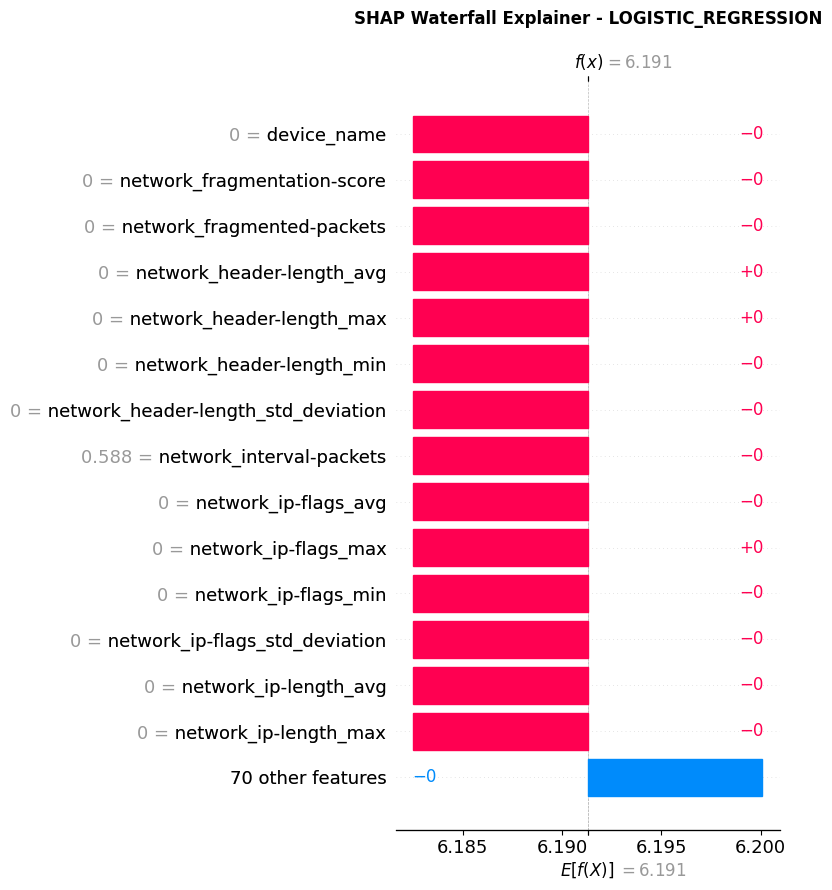


ANALISANDO INSTÂNCIA ÚNICA (WATERFALL): DECISION_TREE


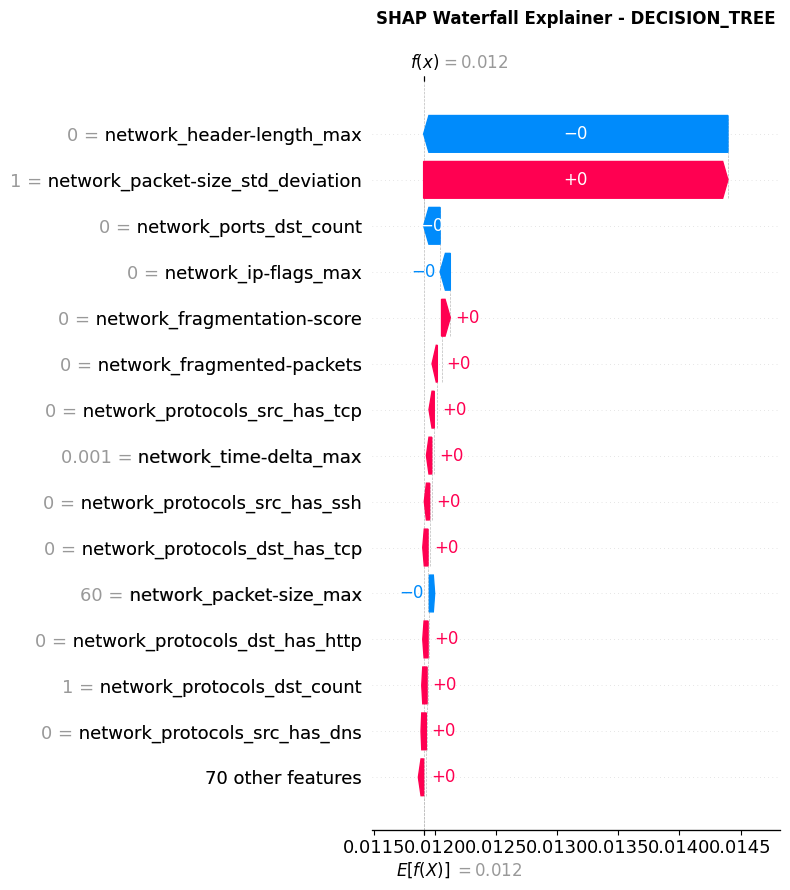


ANALISANDO INSTÂNCIA ÚNICA (WATERFALL): RANDOM_FOREST


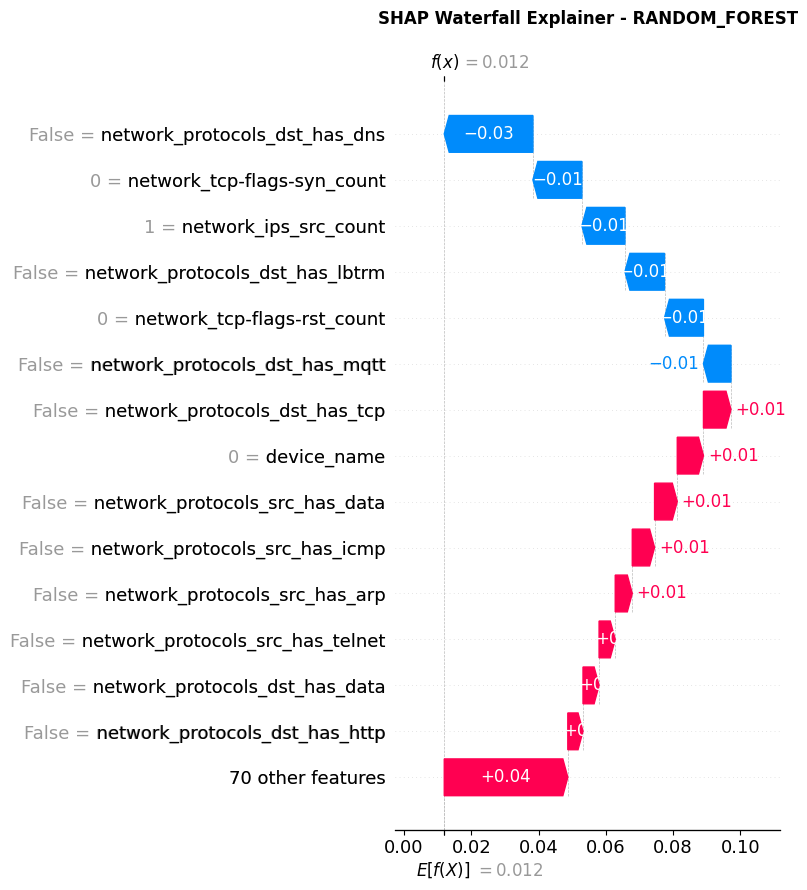

In [41]:
# Extrai exatamente 1 registro do dataset de teste para servir de análise de instância única
single_instance_sample = X_test.sample(n=1, random_state=42)

for name, model in MODELS_BINARY.items():
    print("\n" + "="*60)
    print("ANALISANDO INSTÂNCIA ÚNICA (WATERFALL):", name.upper())
    print("="*60)

    # Isola o pré-processador do modelo final
    if hasattr(model, "named_steps"):
        pre = model[:-1]
        final_model = model[-1]
        # Alinha as colunas da instância com a assinatura esperada pelo preprocessor do pipeline
        expected_cols = pre.feature_names_in_
        X_fixed = single_instance_sample.reindex(columns=expected_cols, fill_value=0)
        X_trans = pre.transform(X_fixed)
    else:
        final_model = model
        X_trans = single_instance_sample

    # Invoca o explicador adequado e captura os valores esperados de base (expected_value)
    if "tree" in name or "forest" in name:
        explainer = shap.TreeExplainer(final_model)
        values = explainer.shap_values(X_trans)
        base_value = explainer.expected_value
    elif "logistic" in name:
        explainer = shap.LinearExplainer(final_model, X_trans)
        values = explainer.shap_values(X_trans)
        base_value = explainer.expected_value
    else:
        explainer = shap.Explainer(final_model, X_trans)
        exp_obj = explainer(X_trans)
        values = exp_obj.values
        base_value = exp_obj.base_values

    # Tratamento e redução de dimensões para arrays redundantes do SHAP binário
    values = np.array(values)
    if isinstance(values, list):
        values = values[1]
    if values.ndim == 3:
        values = values[0, 0, :]
        if isinstance(base_value, (list, np.ndarray)): base_value = base_value[0]
    elif values.ndim == 2:
        values = values[0]
        if isinstance(base_value, (list, np.ndarray)): base_value = base_value[0]

    # Monta o objeto oficial de explicação estruturada exigido pelo gráfico de cascata (waterfall)
    explanation_object = shap.Explanation(
        values=values,
        base_values=base_value,
        data=np.array(X_trans)[0],
        feature_names=single_instance_sample.columns
    )

    # Renderiza o gráfico de cascata limitando a exibição às 15 features mais impactantes
    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(explanation_object, max_display=15, show=False)
    plt.title(f"SHAP Waterfall Explainer - {name.upper()}", fontsize=12, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()
    plt.close()

# 8. ANÁLISE FORENSE DE ERROS (DIAGNÓSTICO FP / FN BINÁRIO - CORRIGIDO)

In [43]:
TOP_K_DISPLAY = 5

for name, model in MODELS_BINARY.items():
    print("\n" + "=" * 80)
    print("ANÁLISE DE FRONTEIRA DE ERROS (BINÁRIO):", name.upper())
    print("=" * 80)

    # Gera o vetor completo de predições com o modelo binário sob o X_test
    predictions = model.predict(X_test)

    # Consolida os dados em um DataFrame de apoio para fatiamento de índices
    error_df = pd.DataFrame({
        "real": y_test_binary.values,
        "pred": predictions
    })

    # Separação estrita dos índices associados a acertos (TP) e erros de classificação (FP e FN)
    TP_indices = error_df[(error_df.real != "benign") & (error_df.pred != "benign")].index
    FP_indices = error_df[(error_df.real == "benign") & (error_df.pred != "benign")].index
    FN_indices = error_df[(error_df.real != "benign") & (error_df.pred == "benign")].index

    print(f"Massa Amostral Disponível -> TP: {len(TP_indices)} | FP: {len(FP_indices)} | FN: {len(FN_indices)}")

    # Executa a extração direcional se houver volumetria mínima em todas as classes
    if len(TP_indices) > 5 and len(FP_indices) > 5 and len(FN_indices) > 5:

        # Extração de amostras aleatórias pareadas de até 500 registros para computação balanceada
        X_tp_slice = X_test.iloc[TP_indices].sample(min(500, len(TP_indices)), random_state=42)
        X_fp_slice = X_test.iloc[FP_indices].sample(min(500, len(FP_indices)), random_state=42)
        X_fn_slice = X_test.iloc[FN_indices].sample(min(500, len(FN_indices)), random_state=42)

        # Computação dos SHAP values originais (MANTENDO SINAIS DIRECIONAIS +/- INTEGROS)
        tp_raw_shap, _ = get_shap(model, X_tp_slice, name)
        fp_raw_shap, _ = get_shap(model, X_fp_slice, name)
        fn_raw_shap, _ = get_shap(model, X_fn_slice, name)

        # Resolve o desempacotamento de listas binárias nativas da biblioteca
        if isinstance(tp_raw_shap, list): tp_raw_shap = tp_raw_shap[1]
        if isinstance(fp_raw_shap, list): fp_raw_shap = fp_raw_shap[1]
        if isinstance(fn_raw_shap, list): fn_raw_shap = fn_raw_shap[1]

        # CORREÇÃO DA ÁLGEBRA: Computa a média simples preservando os sinais antes de qualquer operação
        tp_directional_mean = np.mean(tp_raw_shap, axis=0)
        fp_directional_mean = np.mean(fp_raw_shap, axis=0)
        fn_directional_mean = np.mean(fn_raw_shap, axis=0)

        # BLINDAGEM DE DIMENSÃO: Força os arrays a serem estritamente 1D (unidimensionais), eliminando shapes como (1, N)
        tp_directional_mean = np.ravel(tp_directional_mean)
        fp_directional_mean = np.ravel(fp_directional_mean)
        fn_directional_mean = np.ravel(fn_directional_mean)

        # Captura os nomes oficiais das features válidas pós-pipeline
        valid_feature_names = get_valid_features(model)
        aligned_dim = min(len(valid_feature_names), tp_directional_mean.shape[0])

        # Criação da tabela oficial contendo o balanço e delta de impacto dos erros
        audit_table = pd.DataFrame({
            "feature": valid_feature_names[:aligned_dim],
            "TP_SHAP_Dir": tp_directional_mean[:aligned_dim],
            "FP_SHAP_Dir": fp_directional_mean[:aligned_dim],
            "FN_SHAP_Dir": fn_directional_mean[:aligned_dim]
        })

        # PROPRIEDADE VETORIAL: Subtração direta identifica quais variáveis empurraram a IA para o erro
        audit_table["FP_minus_TP"] = audit_table["FP_SHAP_Dir"] - audit_table["TP_SHAP_Dir"]
        audit_table["FN_minus_TP"] = audit_table["FN_SHAP_Dir"] - audit_table["TP_SHAP_Dir"]

        print(f"\n--- TOP {TOP_K_DISPLAY} DRIVERS QUE INDUZEM FALSOS POSITIVOS (ALARMES FALSOS) ---")
        display(audit_table.sort_values("FP_minus_TP", ascending=False).head(TOP_K_DISPLAY)[["feature", "FP_minus_TP"]])

        print(f"\n--- TOP {TOP_K_DISPLAY} DRIVERS QUE INDUZEM FALSOS NEGATIVOS (EVASÕES DE ATAQUE) ---")
        display(audit_table.sort_values("FN_minus_TP", ascending=False).head(TOP_K_DISPLAY)[["feature", "FN_minus_TP"]])


ANÁLISE DE FRONTEIRA DE ERROS (BINÁRIO): LOGISTIC_REGRESSION
Massa Amostral Disponível -> TP: 20547 | FP: 17888 | FN: 2051

--- TOP 5 DRIVERS QUE INDUZEM FALSOS POSITIVOS (ALARMES FALSOS) ---


,feature,FP_minus_TP
3,network_ip-flags_min,0.925900
38,network_ports_src_has_8000,0.813418
9,network_payload-length_min,0.810710
4,network_ip-flags_std_deviation,0.669952
27,network_protocols_dst_has_ssh,0.508825



--- TOP 5 DRIVERS QUE INDUZEM FALSOS NEGATIVOS (EVASÕES DE ATAQUE) ---


,feature,FN_minus_TP
3,network_ip-flags_min,0.925900
38,network_ports_src_has_8000,0.813418
9,network_payload-length_min,0.810710
4,network_ip-flags_std_deviation,0.669952
27,network_protocols_dst_has_ssh,0.508825



ANÁLISE DE FRONTEIRA DE ERROS (BINÁRIO): DECISION_TREE
Massa Amostral Disponível -> TP: 20184 | FP: 4305 | FN: 2414

--- TOP 5 DRIVERS QUE INDUZEM FALSOS POSITIVOS (ALARMES FALSOS) ---


...

,feature,FN_minus_TP
4,network_header-length_min,0.001282
1,network_fragmented-packets,0.000551
98,network_ports_dst_has_554,0.000240
0,network_fragmentation-score,0.000131
54,network_time-delta_min,0.000068



ANÁLISE DE FRONTEIRA DE ERROS (BINÁRIO): RANDOM_FOREST
Massa Amostral Disponível -> TP: 20527 | FP: 7183 | FN: 2071

--- TOP 5 DRIVERS QUE INDUZEM FALSOS POSITIVOS (ALARMES FALSOS) ---


,feature,FP_minus_TP
86,network_ports_src_has_1883,0.005478
0,network_fragmentation-score,0.004705
85,network_ports_src_has_443,0.004438
32,network_payload-length_avg,0.004198
76,network_protocols_dst_has_http,0.004017



--- TOP 5 DRIVERS QUE INDUZEM FALSOS NEGATIVOS (EVASÕES DE ATAQUE) ---


,feature,FN_minus_TP
0,network_fragmentation-score,0.008048
76,network_protocols_dst_has_http,0.005348
68,network_protocols_src_has_mqtt,0.004712
75,network_protocols_dst_has_tcp,0.003749
6,network_interval-packets,0.003465


# 9. DIAGNÓSTICO FORENSE DE ERROS MULTICLASSE (POR CLASSE - SHAP DIFERENCIAL)

In [46]:
print("="*80)
print("INICIALIZANDO DIAGNÓSTICO FORENSE MULTICLASSE POR CLASSE - TRATADO")
print("="*80)

TOP_K_DISPLAY = 5

for name, model in MODELS_MULTI.items():
    print("\n" + "="*80)
    print("MODELO MULTICLASSE:", name.upper())
    print("="*80)

    pre, final_model = split_pipeline(model)
    classes = final_model.classes_
    feature_names = get_valid_features(model)
    
    n_classes = len(classes)
    n_features = len(feature_names)

    # Gera as predições multiclasse completas no conjunto X_test
    pred_multi = model.predict(X_test)
    
    # --------------------------------------------------------------------------
    # CORREÇÃO CRÍTICA: Aplica o split para extrair a macroclasse do dataset real
    # Ex: 'mitm_arp-spoofing' vira 'mitm'. Se for 'benign', continua 'benign'.
    # --------------------------------------------------------------------------
    real_macrocclasses = [str(val).split('_')[0] for val in y_test_multi.values]

    errors_multi = pd.DataFrame({
        "real": real_macrocclasses, # Agora os nomes vão bater perfeitamente!
        "pred": pred_multi
    })

    for cls_idx, cls_name in enumerate(classes):
        print(f"\n[Analisando Vetores de Erro da Classe]: {cls_name.upper()}")

        TP_idx = errors_multi[(errors_multi.real == cls_name) & (errors_multi.pred == cls_name)].index
        FP_idx = errors_multi[(errors_multi.real != cls_name) & (errors_multi.pred == cls_name)].index
        FN_idx = errors_multi[(errors_multi.real == cls_name) & (errors_multi.pred != cls_name)].index

        print(f"  Amostras Disponíveis -> TP: {len(TP_idx)} | FP: {len(FP_idx)} | FN: {len(FN_idx)}")

        if len(TP_idx) > 5 and len(FP_idx) > 5 and len(FN_idx) > 5:
            X_tp = X_test.iloc[TP_idx].sample(min(300, len(TP_idx)), random_state=42)
            X_fp = X_test.iloc[FP_idx].sample(min(300, len(FP_idx)), random_state=42)
            X_fn = X_test.iloc[FN_idx].sample(min(300, len(FN_idx)), random_state=42)

            tp_cube, _ = get_shap(model, X_tp, name)
            fp_cube, _ = get_shap(model, X_fp, name)
            fn_cube, _ = get_shap(model, X_fn, name)

            tp_cube = normalize_multiclass_dimensions(tp_cube, n_features, n_classes)
            fp_cube = normalize_multiclass_dimensions(fp_cube, n_features, n_classes)
            fn_cube = normalize_multiclass_dimensions(fn_cube, n_features, n_classes)

            tp_mean = np.mean(tp_cube[:, cls_idx, :], axis=0)
            fp_mean = np.mean(fp_cube[:, cls_idx, :], axis=0)
            fn_mean = np.mean(fn_cube[:, cls_idx, :], axis=0)

            tp_mean = np.ravel(tp_mean)
            fp_mean = np.ravel(fp_mean)
            fn_mean = np.ravel(fn_mean)

            aligned_dim = min(len(feature_names), tp_mean.shape[0])

            df_class_error = pd.DataFrame({
                "feature": feature_names[:aligned_dim],
                "TP_SHAP_Dir": tp_mean[:aligned_dim],
                "FP_SHAP_Dir": fp_mean[:aligned_dim],
                "FN_SHAP_Dir": fn_mean[:aligned_dim]
            })

            df_class_error["FP_minus_TP"] = df_class_error["FP_SHAP_Dir"] - df_class_error["TP_SHAP_Dir"]
            df_class_error["FN_minus_TP"] = df_class_error["FN_SHAP_Dir"] - df_class_error["TP_SHAP_Dir"]

            df_class_error.to_csv(FPFN_MULTI_DIR / f"{name}_{cls_name}_error_diagnostic.csv", index=False)

            print(f"    -> Vetores que induzem Falsos Positivos (Tráfego confundido com {cls_name}):")
            display(df_class_error.sort_values("FP_minus_TP", ascending=False).head(TOP_K_DISPLAY)[["feature", "FP_minus_TP"]])

            print(f"    -> Vetores que induzem Falsos Negativos (Ataques de {cls_name} que passaram como benignos):")
            display(df_class_error.sort_values("FN_minus_TP", ascending=False).head(TOP_K_DISPLAY)[["feature", "FN_minus_TP"]])
        else:
            print(f"  [Aviso] Massa de dados insuficiente para gerar diagnóstico forense estável para a classe {cls_name}.")

INICIALIZANDO DIAGNÓSTICO FORENSE MULTICLASSE POR CLASSE - TRATADO

MODELO MULTICLASSE: LOGISTIC_REGRESSION_MULTI

[Analisando Vetores de Erro da Classe]: BENIGN
  Amostras Disponíveis -> TP: 27309 | FP: 3469 | FN: 6891
    -> Vetores que induzem Falsos Positivos (Tráfego confundido com benign):


,feature,FP_minus_TP
0,network_fragmented-packets,0.0
1,network_header-length_std_deviation,0.0
2,network_interval-packets,0.0
3,network_ip-flags_min,0.0
4,network_ip-flags_std_deviation,0.0


    -> Vetores que induzem Falsos Negativos (Ataques de benign que passaram como benignos):


,feature,FN_minus_TP
0,network_fragmented-packets,0.0
1,network_header-length_std_deviation,0.0
2,network_interval-packets,0.0
3,network_ip-flags_min,0.0
4,network_ip-flags_std_deviation,0.0



[Analisando Vetores de Erro da Classe]: BRUTEFORCE
  Amostras Disponíveis -> TP: 329 | FP: 2641 | FN: 136
    -> Vetores que induzem Falsos Positivos (Tráfego confundido com bruteforce):


...


[Analisando Vetores de Erro da Classe]: RECON
  Amostras Disponíveis -> TP: 6455 | FP: 445 | FN: 1990
    -> Vetores que induzem Falsos Positivos (Tráfego confundido com recon):


,feature,FP_minus_TP
0,network_fragmentation-score,0.000263
7,network_ip-flags_avg,0.000177
1,network_fragmented-packets,0.000091
2,network_header-length_avg,0.000014
3,network_header-length_max,-0.000056


    -> Vetores que induzem Falsos Negativos (Ataques de recon que passaram como benignos):


,feature,FN_minus_TP
1,network_fragmented-packets,0.000271
2,network_header-length_avg,0.000149
6,network_interval-packets,0.000120
7,network_ip-flags_avg,0.000048
4,network_header-length_min,0.000039



[Analisando Vetores de Erro da Classe]: WEB
  Amostras Disponíveis -> TP: 698 | FP: 1064 | FN: 1
  [Aviso] Massa de dados insuficiente para gerar diagnóstico forense estável para a classe web.


In [29]:

# SHAP GLOBAL MULTICLASSE
# REMOVE FEATURES "device"


sample=X_test.sample(
    300,
    random_state=42
)

for name,model in MODELS_MULTI.items():

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    values,X_trans=get_shap_multi(
        model,
        sample,
        name
    )

    values=np.array(values)

    pre,final_model=split_pipeline(
        model
    )


    # ========================================================
    # CLASSES
    # ========================================================

    classes=final_model.classes_

    print(
        "Classes modelo:"
    )

    print(
        classes
    )


    # ========================================================
    # FEATURES
    # ========================================================

    try:

        feature_names=(
            pre.get_feature_names_out()
        )

    except:

        feature_names=np.array(
            X_test.columns
        )


    n_features=len(
        feature_names
    )

    n_classes=len(
        classes
    )


    print(
        "Shape original:",
        values.shape
    )


    # ========================================================
    # AJUSTA DIMENSÕES
    # ========================================================

    if values.ndim==3:

        # (samples,features,classes)

        if values.shape[1]==n_features:

            values=np.transpose(
                values,
                (0,2,1)
            )

        # (classes,samples,features)

        elif values.shape[0]==n_classes:

            values=np.transpose(
                values,
                (1,0,2)
            )


    print(
        "Shape ajustado:",
        values.shape
    )


    # ========================================================
    # REMOVE FEATURES DEVICE
    # ========================================================

    keep_idx=[

        i

        for i,f in enumerate(
            feature_names
        )

        if "device" not in f.lower()

    ]


    filtered_features=feature_names[
        keep_idx
    ]


    print(
        "\nFeatures removidas:"
    )

    removed=[

        f

        for f in feature_names

        if "device" in f.lower()

    ]

    print(
        removed
    )


    # ========================================================
    # LOOP CLASSES
    # ========================================================

    max_classes=min(

        n_classes,
        values.shape[1]

    )


    for i in range(
        max_classes
    ):

        cls=classes[i]

        print(
            "\nClasse:",
            cls
        )

        class_values=values[
            :,
            i,
            keep_idx
        ]


        importance=np.mean(

            np.abs(
                class_values
            ),

            axis=0

        )


        df=pd.DataFrame({

            "feature":
            filtered_features,

            "importance":
            importance

        })


        display(

            df
            .sort_values(
                "importance",
                ascending=False
            )
            .head(10)

        )



logistic_regression_multi
Classes modelo:
['benign' 'bruteforce' 'ddos' 'dos' 'malware' 'mitm' 'recon' 'web']
Shape original: (300, 49, 8)
Shape ajustado: (300, 8, 49)

Features removidas:
['device_type_infra', 'device_type_iot']

Classe: benign


,feature,importance
10,network_ports_src_count,1.730003
17,network_window-size_min,0.576726
9,network_payload-length_min,0.446383
5,network_mss_min,0.399922
12,network_tcp-flags-psh_count,0.387768
0,network_fragmented-packets,0.355104
43,network_ports_dst_has_80,0.344436
44,network_ports_dst_has_23,0.342145
30,network_protocols_dst_has_mqtt,0.314425
11,network_tcp-flags-fin_count,0.230601



Classe: bruteforce


,feature,importance
43,network_ports_dst_has_80,1.193467
10,network_ports_src_count,1.047427
12,network_tcp-flags-psh_count,0.970817
37,network_ports_src_has_80,0.806133
30,network_protocols_dst_has_mqtt,0.782694
44,network_ports_dst_has_23,0.775566
23,network_protocols_src_has_telnet,0.533620
29,network_protocols_dst_has_data,0.463485
41,network_ports_dst_has_443,0.461375
4,network_ip-flags_std_deviation,0.438611



Classe: ddos


...

,feature,importance
27,network_packet-size_min,0.031532
30,network_packets_dst_count,0.017924
29,network_packets_all_count,0.014146
62,network_window-size_min,0.012800
13,network_ip-length_min,0.011425
36,network_ports_all_count,0.010569
11,network_ip-length_avg,0.010224
63,network_window-size_std_deviation,0.008397
61,network_window-size_max,0.007660
60,network_window-size_avg,0.006258



Classe: recon


,feature,importance
58,network_ttl_min,0.022106
30,network_packets_dst_count,0.021028
45,network_tcp-flags-rst_count,0.018602
51,network_tcp-flags_std_deviation,0.017959
29,network_packets_all_count,0.016628
62,network_window-size_min,0.014651
60,network_window-size_avg,0.012196
27,network_packet-size_min,0.012062
46,network_tcp-flags-syn_count,0.010987
22,network_mss_max,0.010097



Classe: web


,feature,importance
13,network_ip-length_min,0.015860
58,network_ttl_min,0.012326
18,network_macs_all_count,0.009997
30,network_packets_dst_count,0.007953
48,network_tcp-flags_avg,0.006182
29,network_packets_all_count,0.005682
59,network_ttl_std_deviation,0.004571
15,network_ips_all_count,0.004448
25,network_packet-size_avg,0.004398
27,network_packet-size_min,0.004106


# 12. COMPILAÇÃO GRÁFICA (DPI=300)

In [ ]:
print("[ROTIINA VISUAL] Processando arquivos de dados para gerar gráficos do artigo...")

TOP_N = 15
for csv_file_path in SHAP_GLOBAL_DIR.glob("*.csv"):
    chart_data_df = pd.read_csv(csv_file_path).head(TOP_N)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    target_importance_col = "importance" if "importance" in chart_data_df.columns else "importance_macro"
    
    ax.barh(
        chart_data_df["feature"].iloc[::-1], 
        chart_data_df[target_importance_col].iloc[::-1], 
        color="#1f77b4", 
        edgecolor="none"
    )
    
    ax.set_xlabel("Mean |SHAP Value| (Impacto Médio na Saída do Modelo)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Atributos de Fluxo de Rede (Features)", fontsize=11, fontweight="bold")
    ax.set_title(f"Importância de Atributos - {csv_file_path.stem.replace('_', ' ').upper()}", fontsize=12, fontweight="bold", pad=15)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"plot_{csv_file_path.stem}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"\n[SUCESSO] Notebook atualizado e executado por completo. Gráficos gerados em: {FIG_DIR}")



LOGISTIC_REGRESSION_MULTI


Classe: benign
TP=27309 FP=3469 FN=6891
Features: 49
TP: 49

TOP FP


,feature,TP,FP,FN,FP_minus_TP,FN_minus_TP
17,network_window-size_min,0.568078,0.599142,0.557895,0.031064,-0.010183
10,network_ports_src_count,0.436191,0.453648,0.684648,0.017456,0.248457
12,network_tcp-flags-psh_count,0.196078,0.205429,0.422237,0.009351,0.226160
43,network_ports_dst_has_443,0.000000,0.007524,0.030095,0.007524,0.030095
23,network_protocols_src_has_mqtt,0.052121,0.055321,0.043978,0.003200,-0.008142



TOP FN


,feature,TP,FP,FN,FP_minus_TP,FN_minus_TP
19,device_type_iot,0.133938,0.080363,3.849389,-0.053575,3.715451
18,device_type_infra,0.076565,0.045939,2.093892,-0.030626,2.017328
32,network_protocols_dst_has_mqtt,0.008037,0.000000,0.642675,-0.008037,0.634637
3,network_ip-flags_min,0.045558,0.020522,0.348459,-0.025037,0.302901
10,network_ports_src_count,0.436191,0.453648,0.684648,0.017456,0.248457




Classe: bruteforce
TP=0 FP=2970 FN=0


Classe: ddos
TP=0 FP=3471 FN=0


Classe: dos
TP=0 FP=4364 FN=0


Classe: malware
TP=0 FP=1947 FN=0


Classe: mitm
TP=0 FP=4512 FN=0


Classe: recon
TP=0 FP=6994 FN=0


Classe: web
TP=0 FP=1762 FN=0


DECISION_TREE_MULTI


Classe: benign
TP=30717 FP=2420 FN=3483
Features: 107
TP: 107

TOP FP


...



Classe: bruteforce
TP=0 FP=2253 FN=0


Classe: ddos
TP=0 FP=4116 FN=0


Classe: dos
TP=0 FP=4365 FN=0


Classe: malware
TP=0 FP=2143 FN=0


Classe: mitm
TP=0 FP=2093 FN=0


Classe: recon
TP=0 FP=6964 FN=0


Classe: web
TP=0 FP=1727 FN=0


RANDOM_FOREST_MULTI


Classe: benign
TP=30702 FP=2464 FN=3498
Features: 107
TP: 107

TOP FP


,feature,TP,FP,FN,FP_minus_TP,FN_minus_TP
56,network_time-delta_max,0.005587,0.007238,0.004547,0.001651,-0.001040
57,network_time-delta_min,0.005803,0.007115,0.004317,0.001312,-0.001486
55,network_time-delta_avg,0.008609,0.009543,0.006383,0.000934,-0.002226
62,network_ttl_std_deviation,0.005185,0.005713,0.002625,0.000528,-0.002561
1,device_type_infra,0.003314,0.003782,0.007495,0.000468,0.004181



TOP FN


,feature,TP,FP,FN,FP_minus_TP,FN_minus_TP
1,device_type_infra,0.003314,0.003782,0.007495,0.000468,0.004181
45,network_tcp-flags-ack_count,0.000309,0.000233,0.000646,-0.000076,0.000338
90,network_ports_src_has_22,0.000320,0.000341,0.000628,0.000022,0.000309
29,network_packet-size_max,0.001733,0.001683,0.002036,-0.000051,0.000303
52,network_tcp-flags_max,0.000370,0.000311,0.000576,-0.000059,0.000205




Classe: bruteforce
TP=0 FP=2401 FN=0


Classe: ddos
TP=0 FP=3882 FN=0


Classe: dos
TP=0 FP=4366 FN=0


Classe: malware
TP=0 FP=2059 FN=0


Classe: mitm
TP=0 FP=2262 FN=0


Classe: recon
TP=0 FP=6900 FN=0


Classe: web
TP=0 FP=1762 FN=0


# 11. GRÁFICOS SHAP


Gerando gráficos binários...


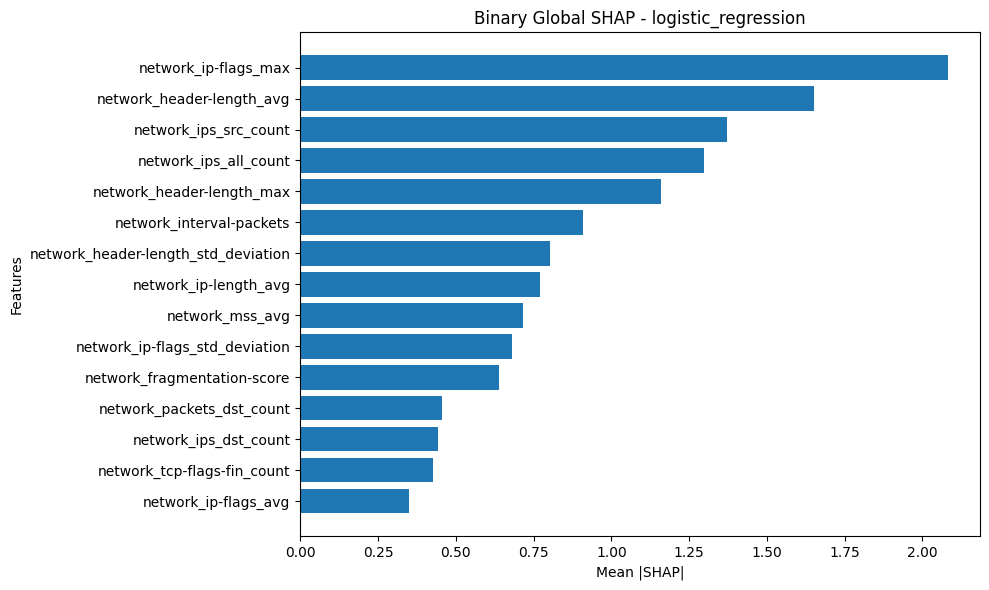

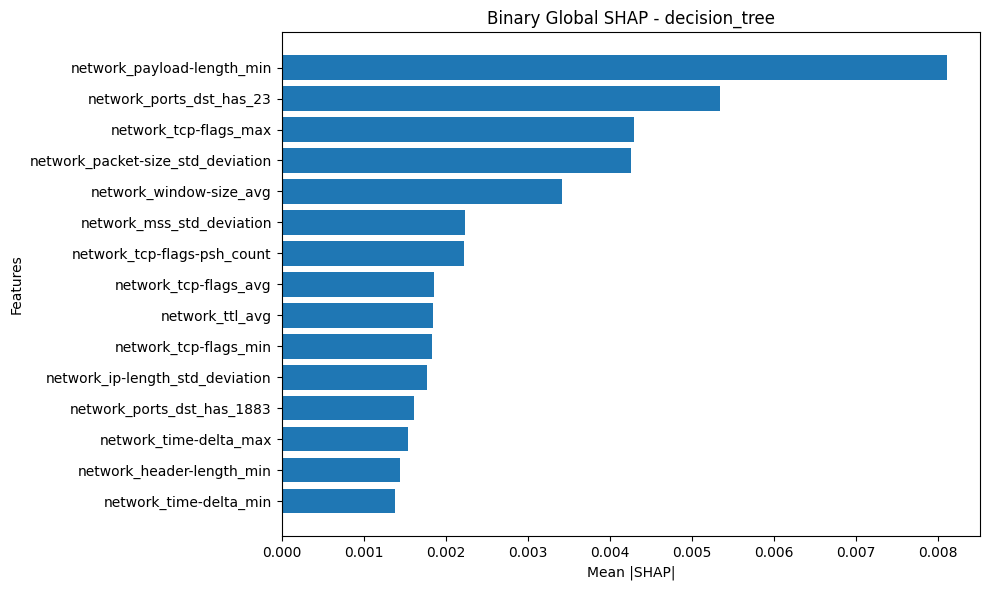

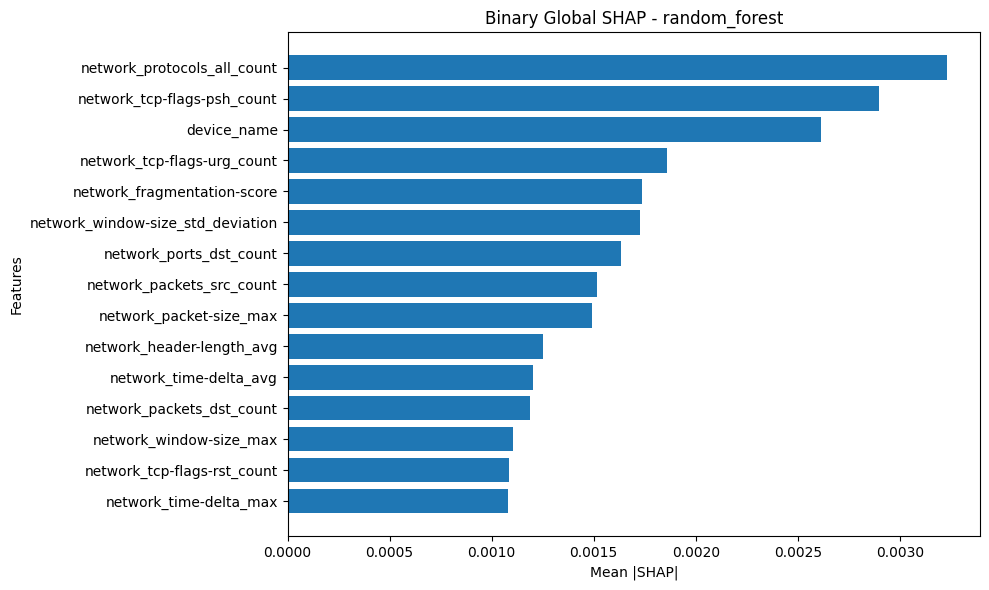


Gerando multiclass macro...


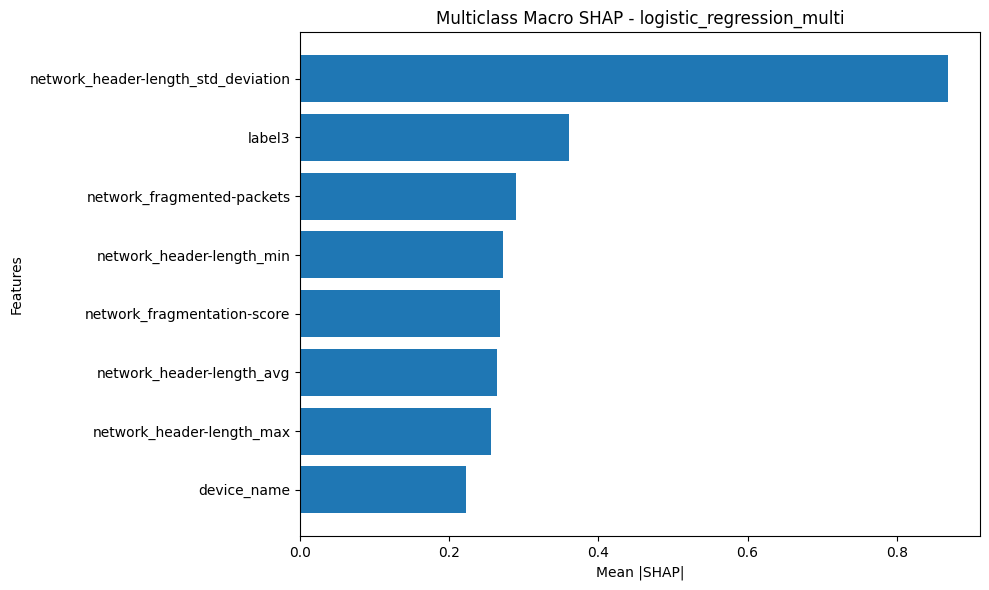

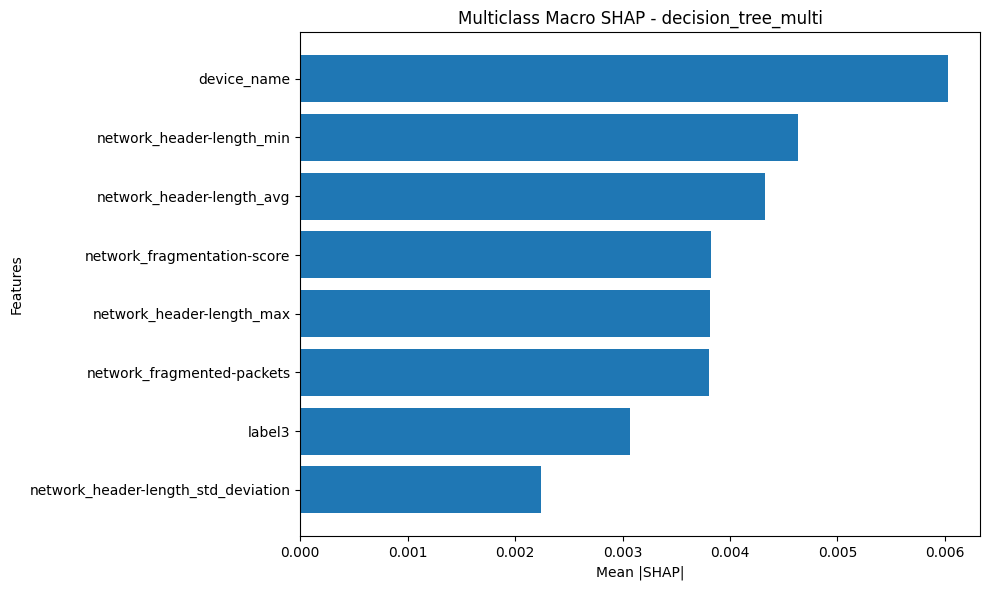

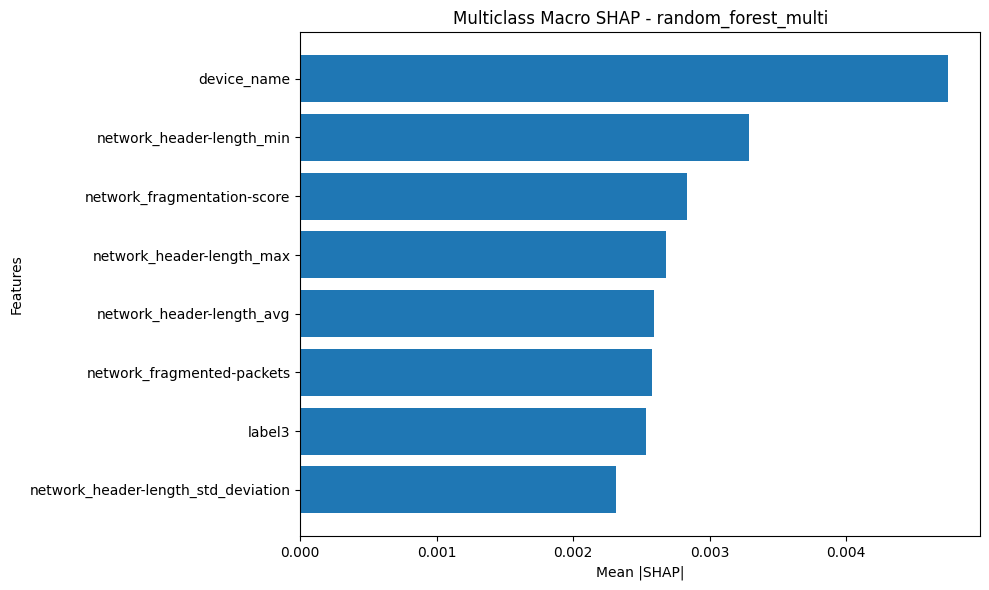


Gerando SHAP por classe...


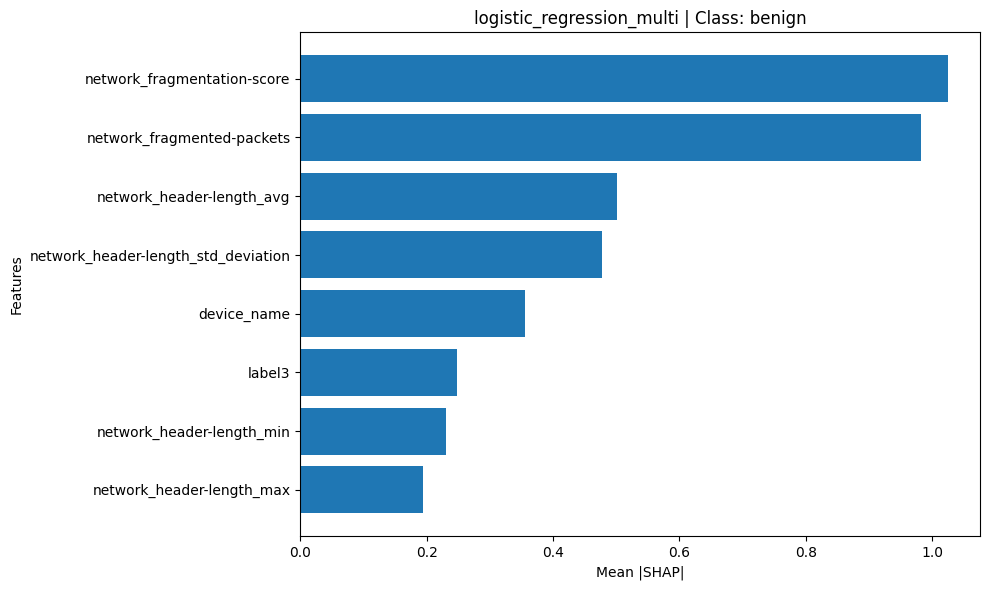

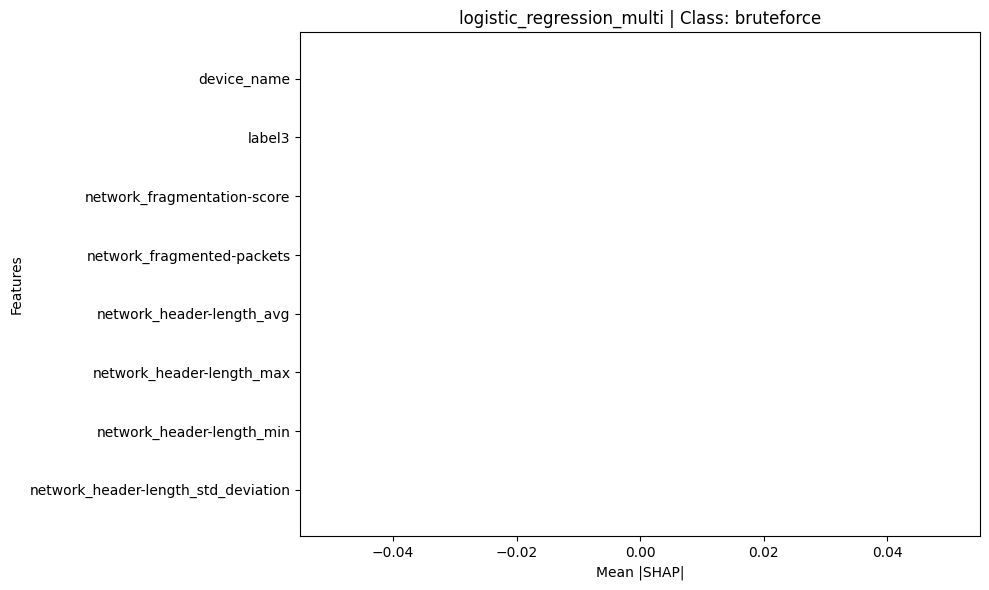

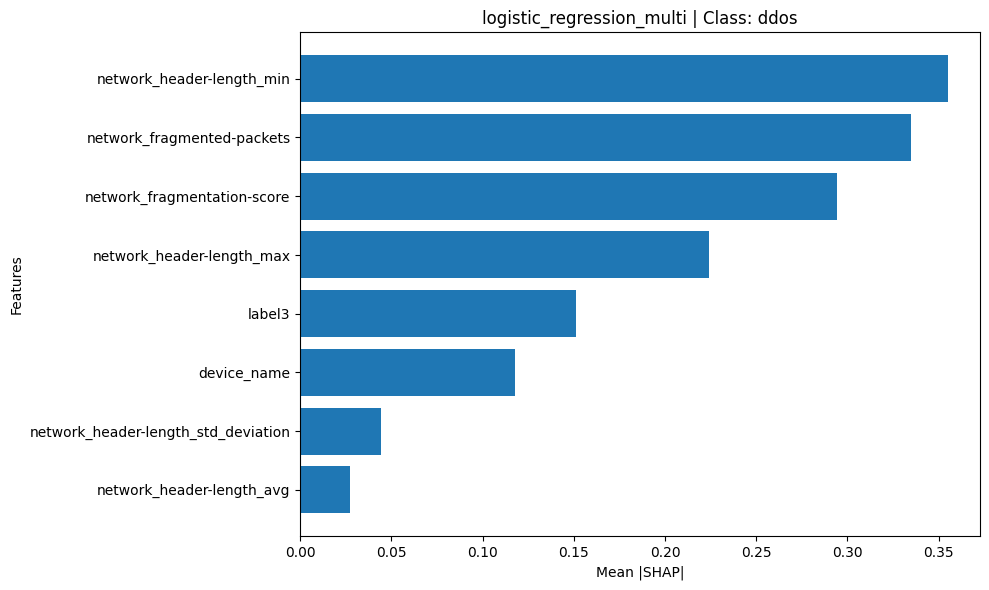

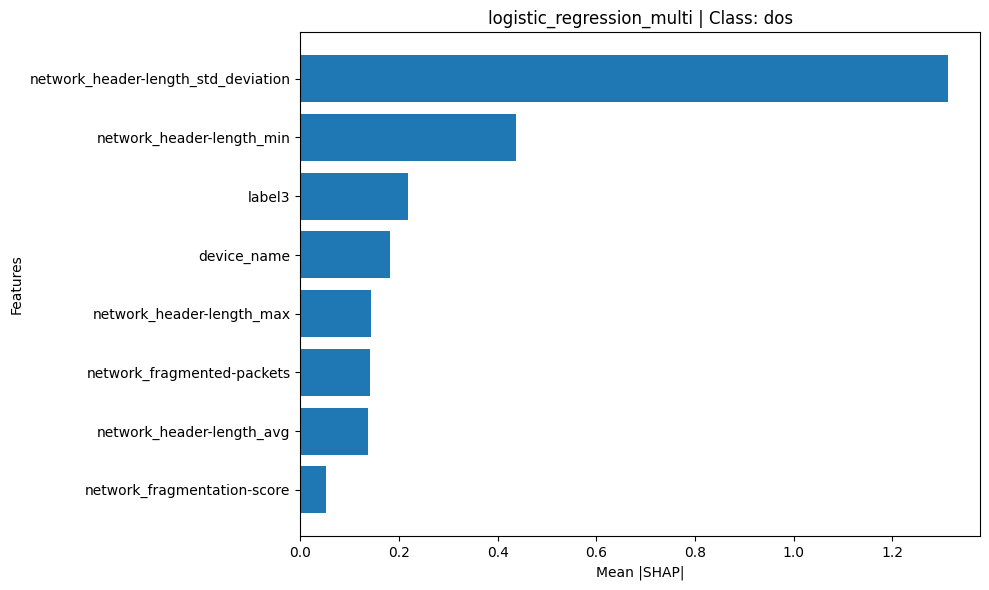

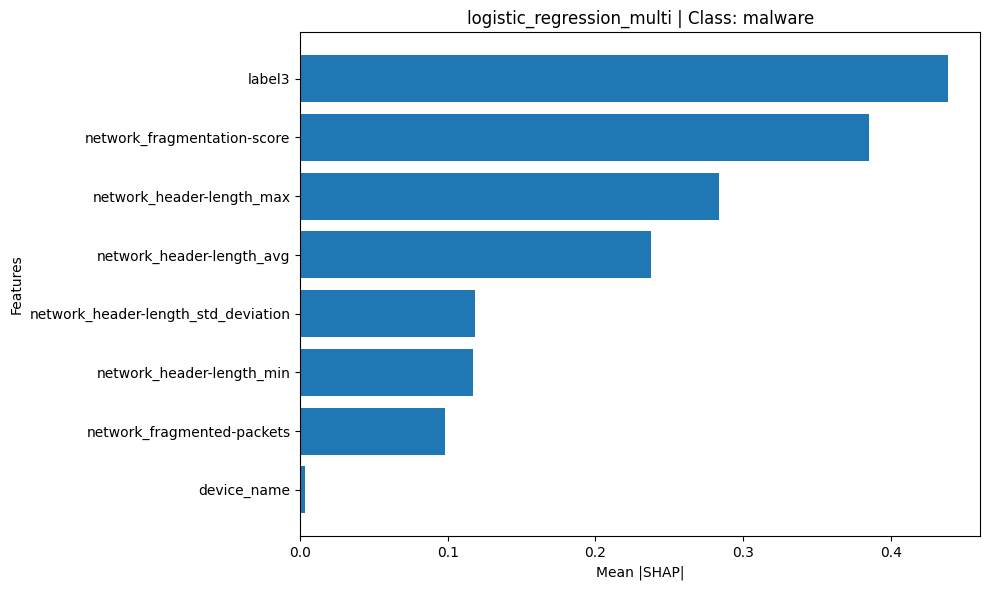

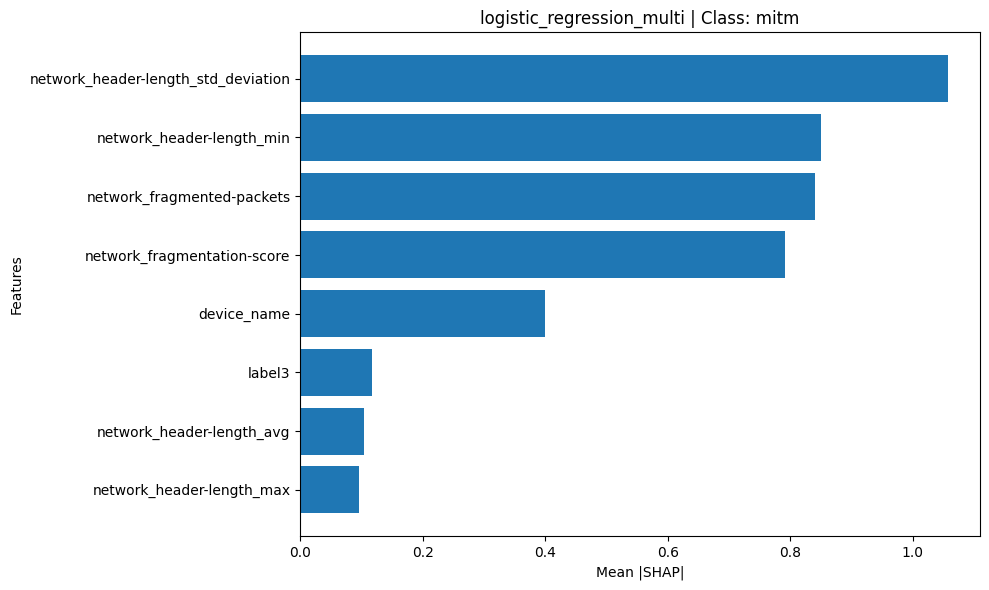

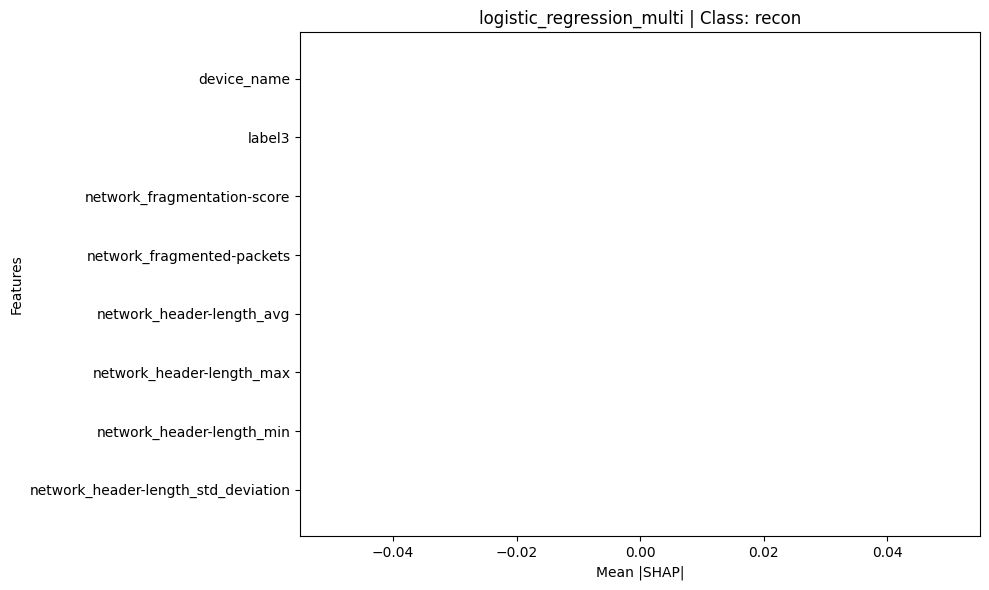

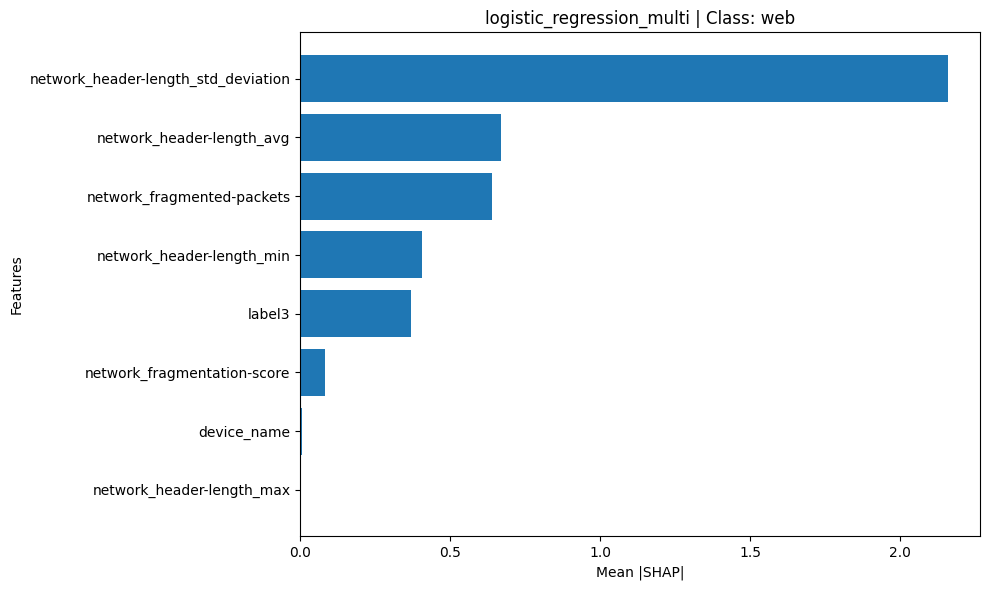

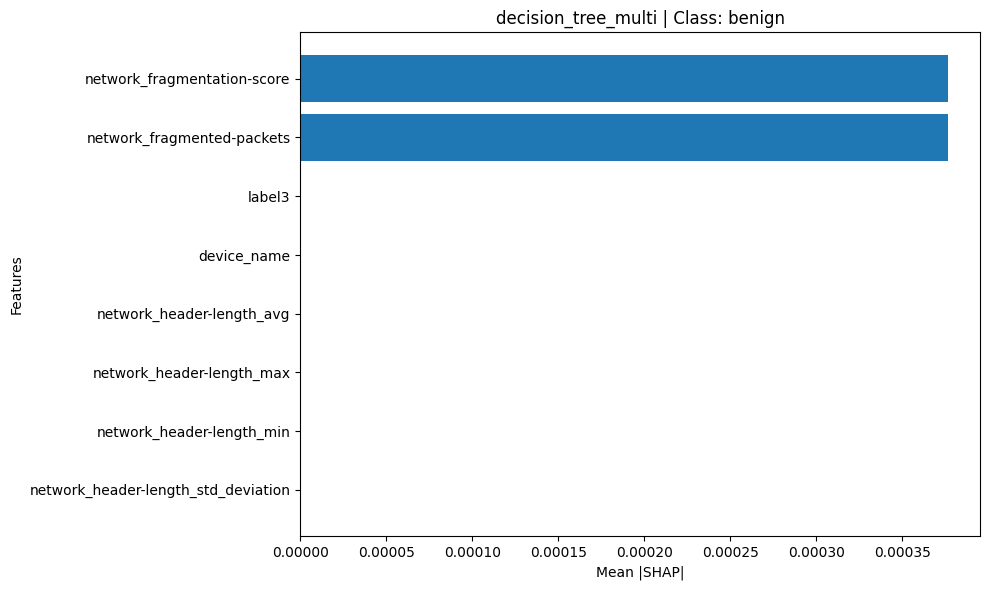

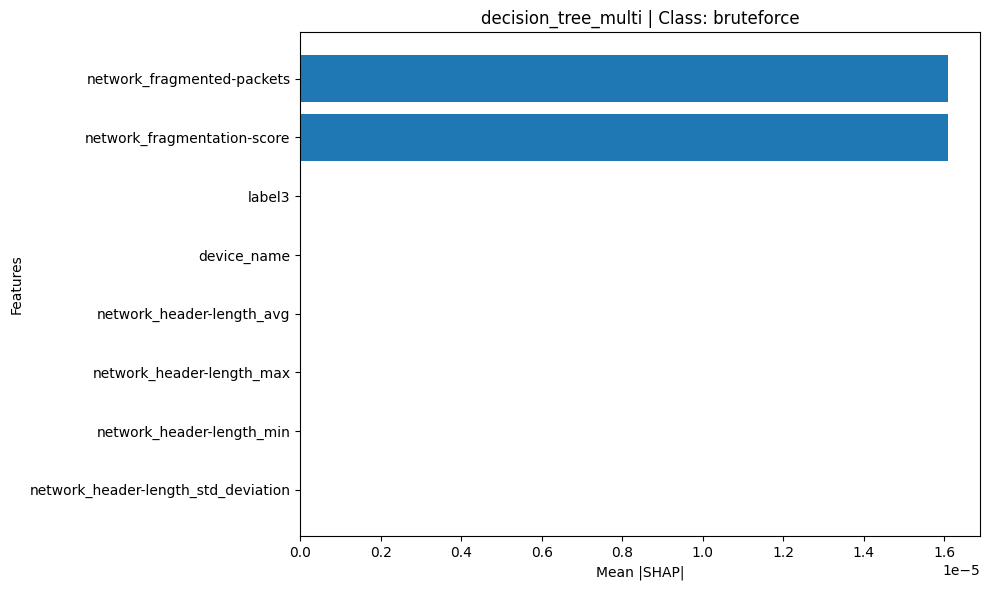

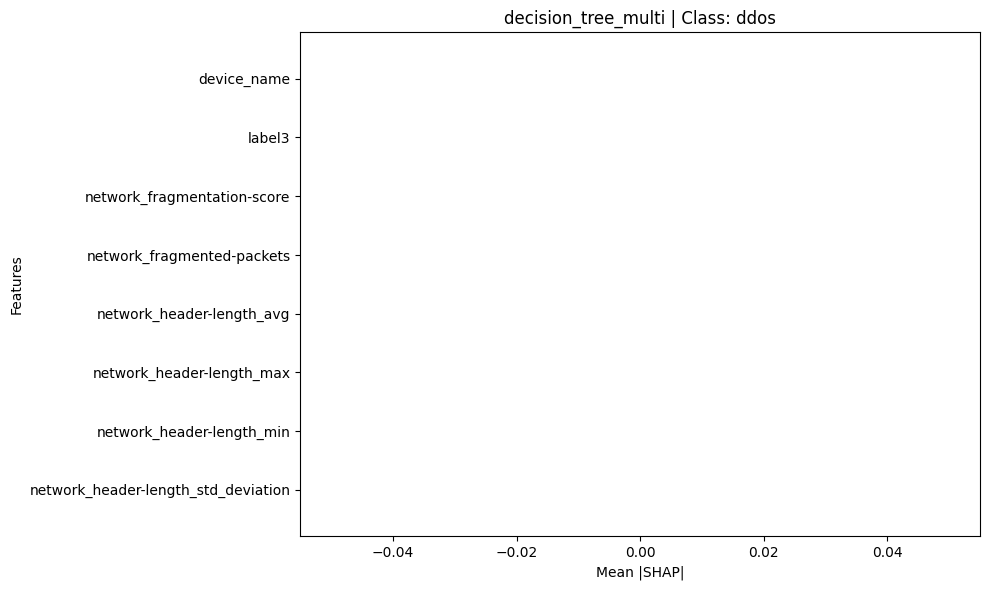

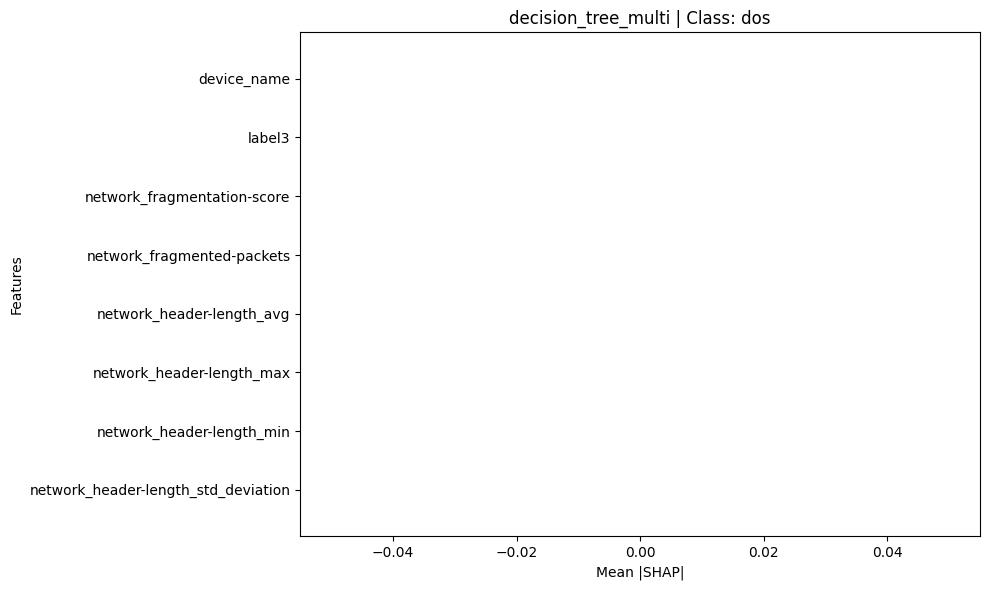

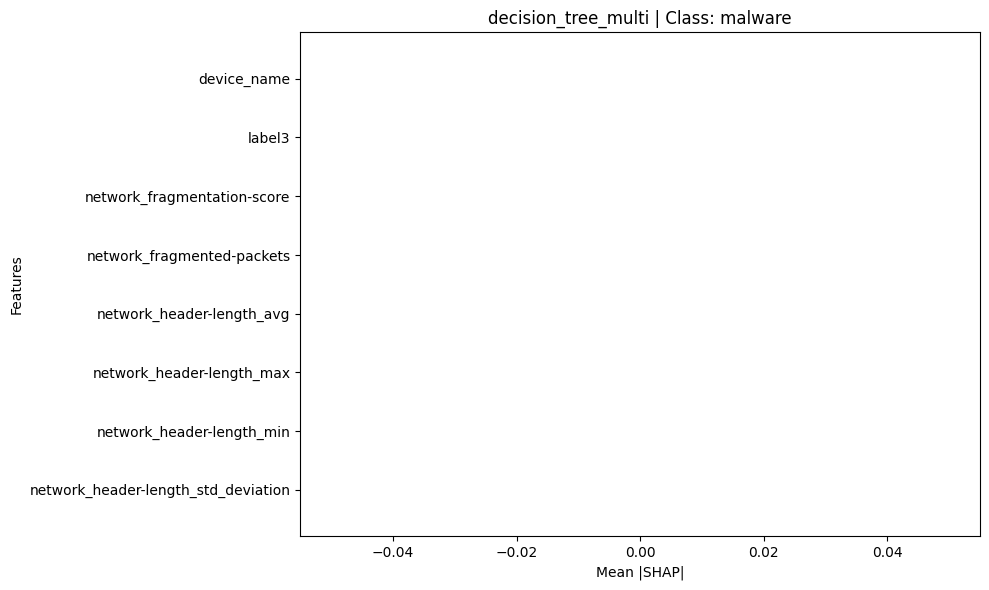

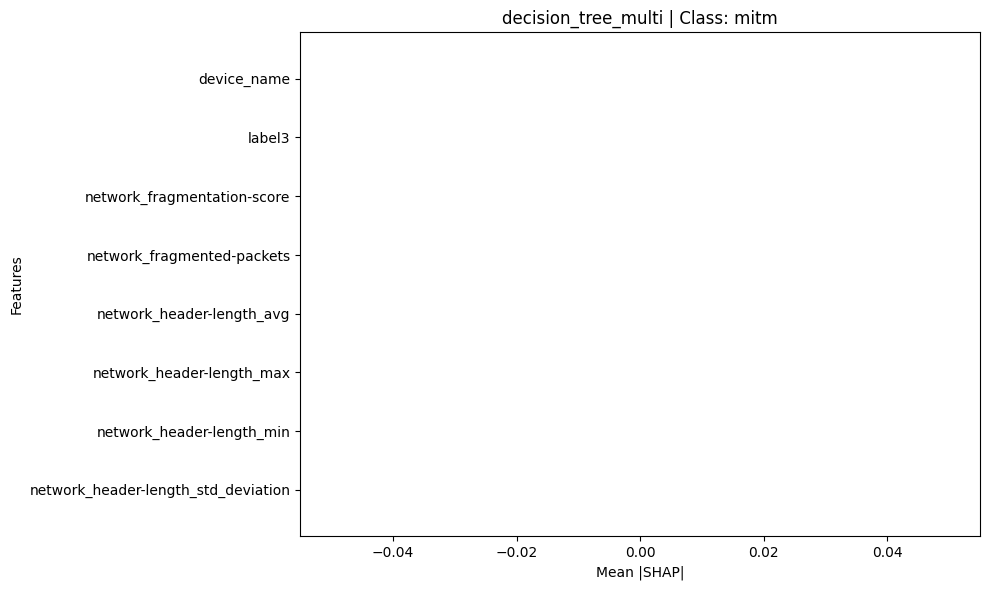

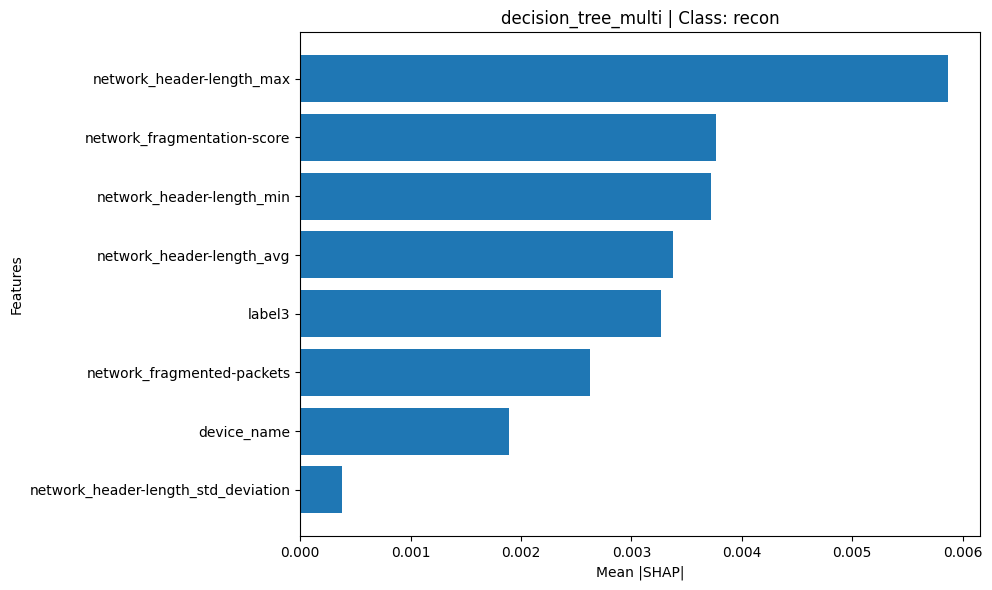

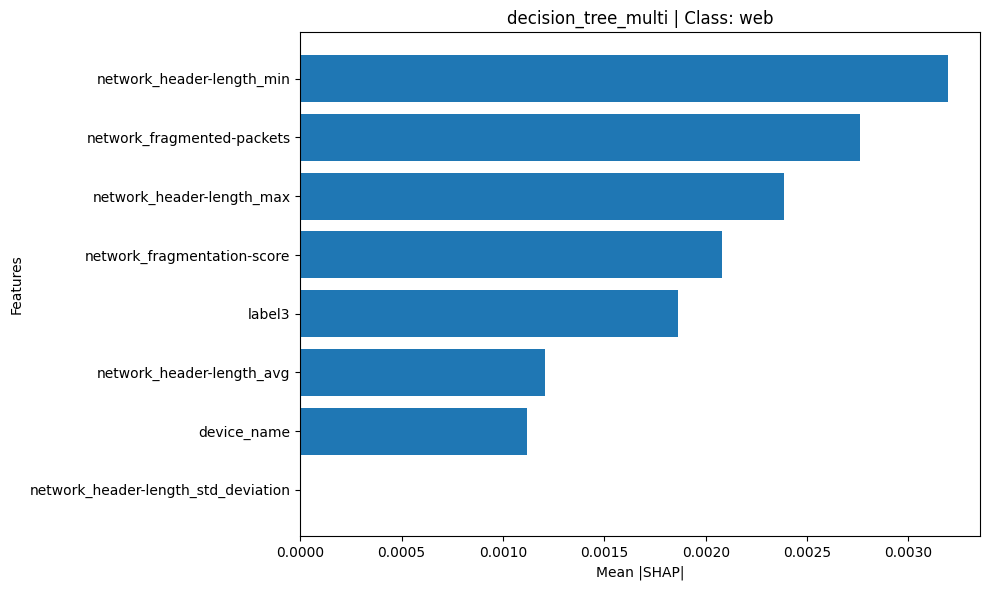

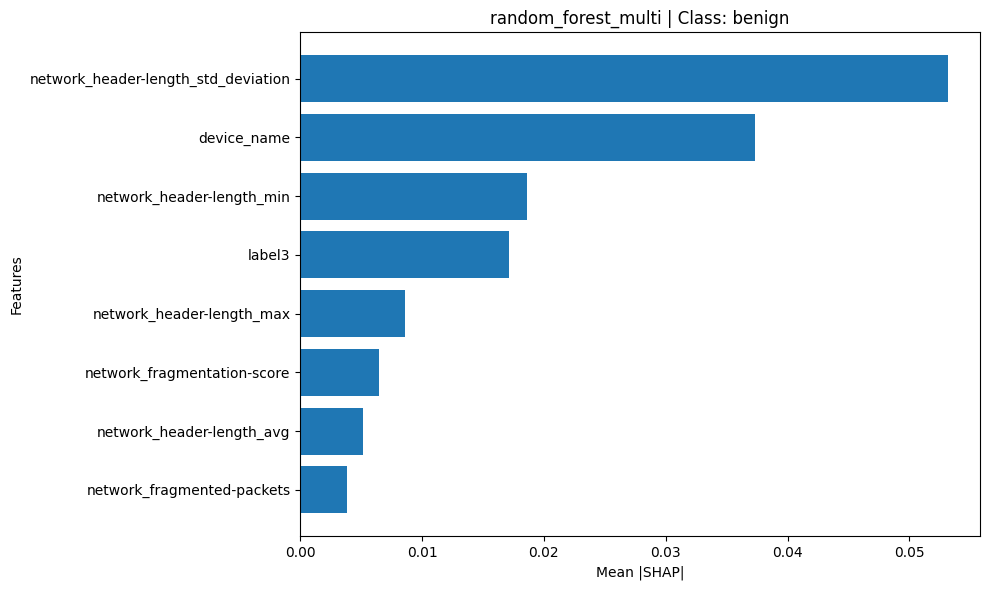

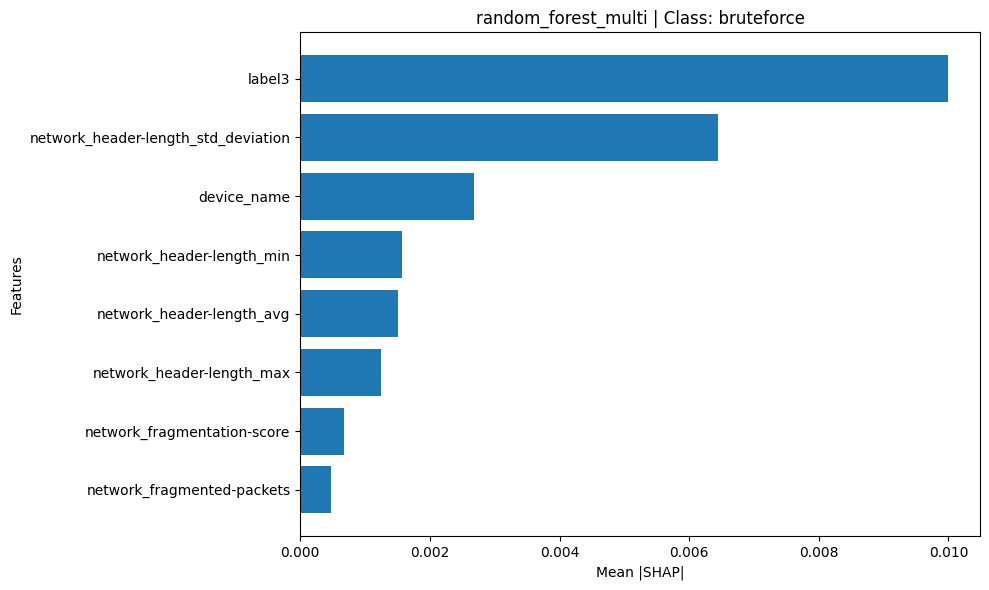

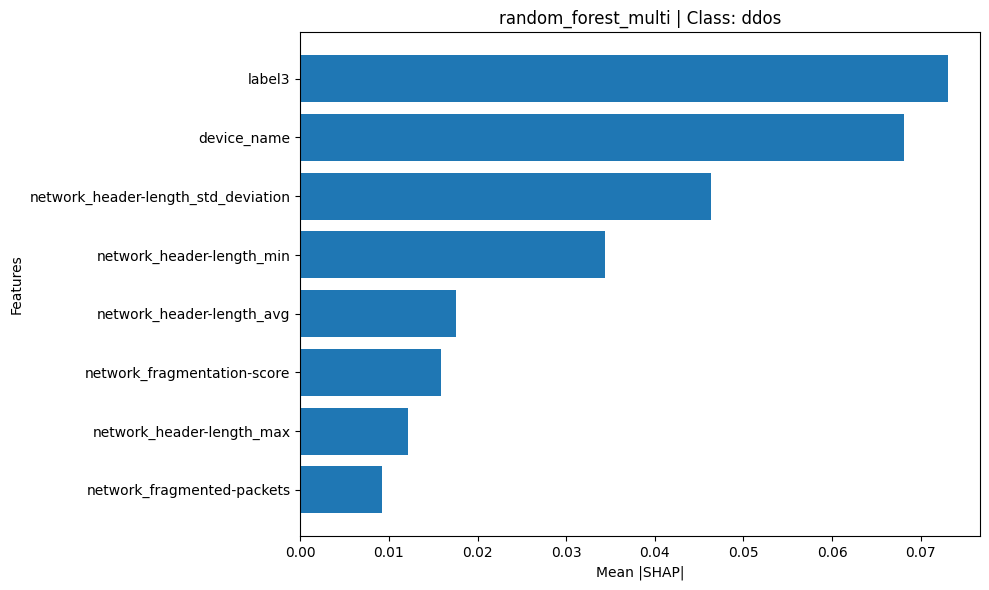

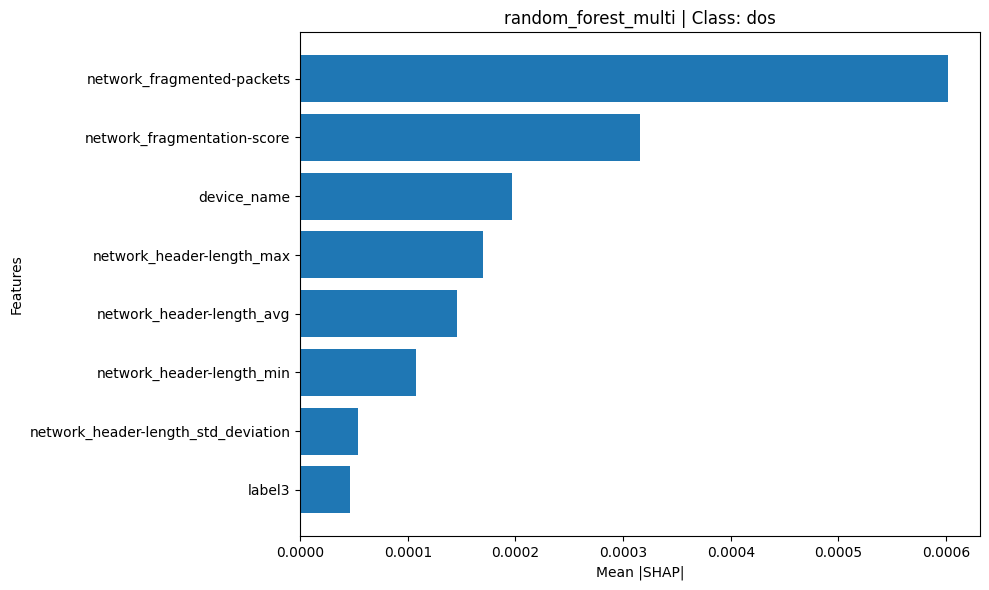

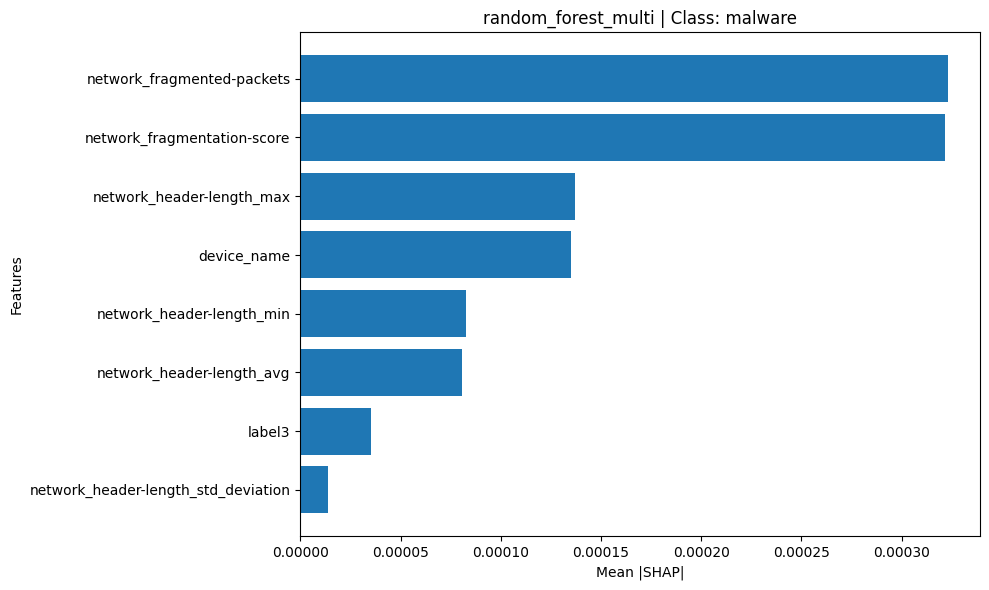

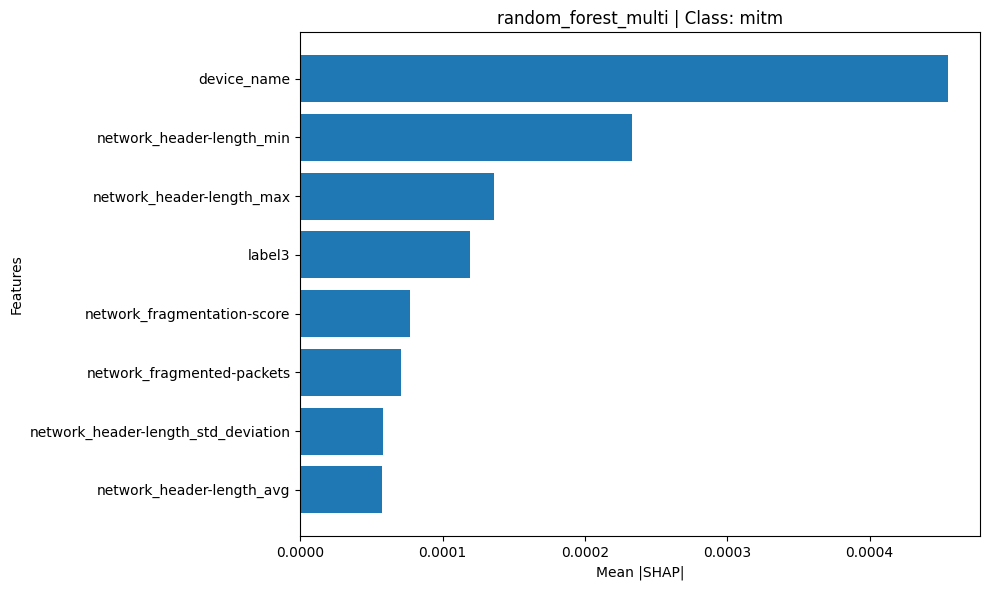

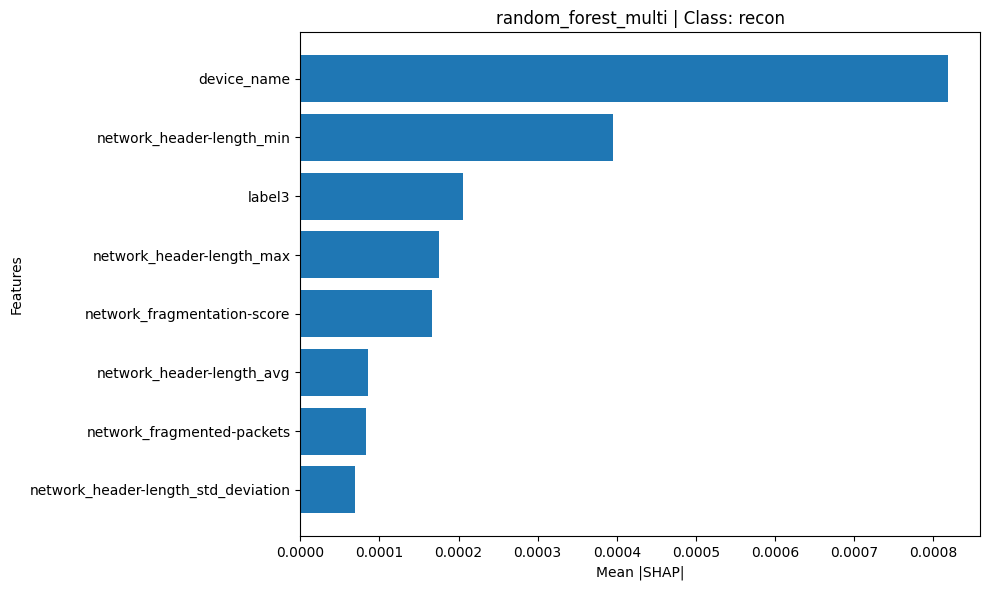

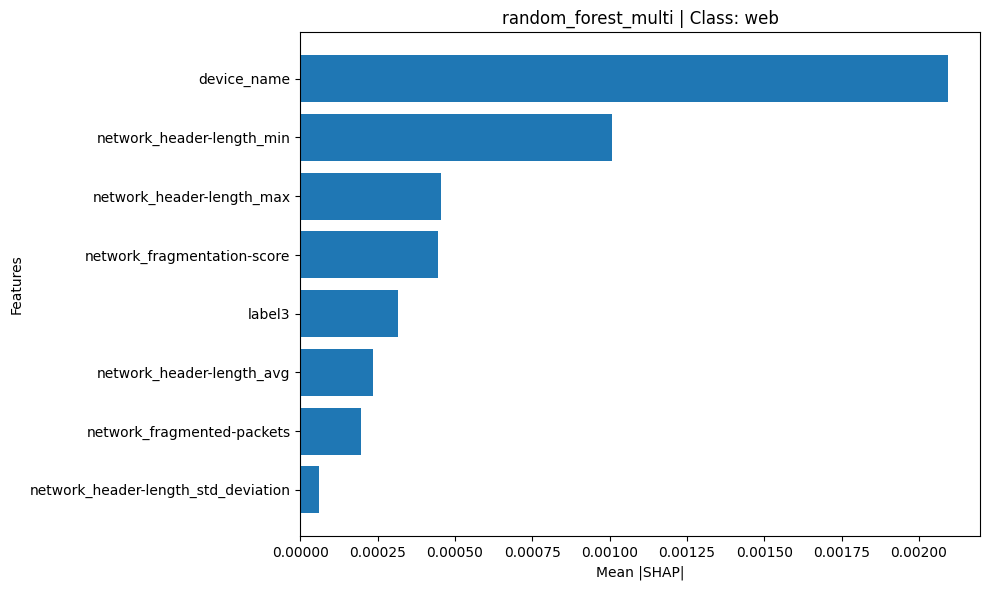



FIGURAS SALVAS
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\experiments\results_xai\figures


In [31]:

# GRÁFICOS ACADÊMICOS SHAP
#
# Gera:
#
# BINÁRIO
# - SHAP Global (3 modelos)
#
# MULTICLASSE
# - SHAP Global Macro (3 modelos)
# - SHAP por classe (micro)
#
# Salva automaticamente
#


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path


# DIRETÓRIO


FIG_DIR=(
    PROJECT_ROOT/
    "experiments"/
    "results_xai"/
    "figures"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TOP_N=15


# AUXILIAR


def normalize_multiclass(values,n_features,n_classes):

    values=np.array(values)

    if values.ndim==3:

        #(samples,features,classes)

        if values.shape[1]==n_features:

            values=np.transpose(
                values,
                (0,2,1)
            )

        #(classes,samples,features)

        elif values.shape[0]==n_classes:

            values=np.transpose(
                values,
                (1,0,2)
            )

    return values



# BINÁRIO - GLOBAL


print("\nGerando gráficos binários...")

sample=X_test.sample(
    min(
        300,
        len(X_test)
    ),
    random_state=42
)

for name,model in MODELS_BINARY.items():

    values,_=get_shap(
        model,
        sample,
        name
    )

    vals=reduce_shap(
        values
    )

    df=pd.DataFrame({

        "feature":
        X_test.columns[:len(vals)],

        "importance":
        vals

    })

    df=df.sort_values(

        "importance",
        ascending=False

    ).head(TOP_N)


    plt.figure(
        figsize=(10,6)
    )

    plt.barh(

        df.feature.iloc[::-1],
        df.importance.iloc[::-1]

    )

    plt.xlabel(
        "Mean |SHAP|"
    )

    plt.ylabel(
        "Features"
    )

    plt.title(
        f"Binary Global SHAP - {name}"
    )

    plt.tight_layout()

    plt.savefig(

        FIG_DIR/
        f"{name}_binary_global.png",

        dpi=300,
        bbox_inches="tight"

    )

    plt.show()

    plt.close()




# MULTICLASSE - GLOBAL MACRO


print(
    "\nGerando multiclass macro..."
)

for name,model in MODELS_MULTI.items():

    values,_=get_shap_multi(

        model,
        sample,
        name

    )

    values=np.array(
        values
    )

    pre,final_model=split_pipeline(
        model
    )

    classes=final_model.classes_

    n_classes=len(
        classes
    )

    n_features=len(
        X_test.columns
    )

    values=normalize_multiclass(

        values,
        n_features,
        n_classes

    )


    macro=np.mean(

        np.abs(values),

        axis=(0,1)

    )


    df=pd.DataFrame({

        "feature":
        X_test.columns[:len(macro)],

        "importance":
        macro

    })

    df=df.sort_values(

        "importance",
        ascending=False

    ).head(TOP_N)


    plt.figure(
        figsize=(10,6)
    )

    plt.barh(

        df.feature.iloc[::-1],
        df.importance.iloc[::-1]

    )

    plt.xlabel(
        "Mean |SHAP|"
    )

    plt.ylabel(
        "Features"
    )

    plt.title(
        f"Multiclass Macro SHAP - {name}"
    )

    plt.tight_layout()

    plt.savefig(

        FIG_DIR/
        f"{name}_multiclass_macro.png",

        dpi=300,
        bbox_inches="tight"

    )

    plt.show()

    plt.close()



# MULTICLASSE - MICRO (por classe)


print(
    "\nGerando SHAP por classe..."
)

for name,model in MODELS_MULTI.items():

    values,_=get_shap_multi(

        model,
        sample,
        name

    )

    values=np.array(
        values
    )

    pre,final_model=split_pipeline(
        model
    )

    classes=final_model.classes_

    n_classes=len(
        classes
    )

    n_features=len(
        X_test.columns
    )


    values=normalize_multiclass(

        values,
        n_features,
        n_classes

    )


    for i,cls in enumerate(
        classes
    ):

        class_values=np.mean(

            np.abs(
                values[:,i,:]
            ),

            axis=0

        )


        df=pd.DataFrame({

            "feature":
            X_test.columns[:len(class_values)],

            "importance":
            class_values

        })

        df=df.sort_values(

            "importance",
            ascending=False

        ).head(TOP_N)


        plt.figure(
            figsize=(10,6)
        )

        plt.barh(

            df.feature.iloc[::-1],
            df.importance.iloc[::-1]

        )

        plt.xlabel(
            "Mean |SHAP|"
        )

        plt.ylabel(
            "Features"
        )

        plt.title(

            f"{name} | Class: {cls}"

        )

        plt.tight_layout()

        plt.savefig(

            FIG_DIR/
            f"{name}_{cls}_micro.png",

            dpi=300,
            bbox_inches="tight"

        )

        plt.show()

        plt.close()



print("\n")
print("="*60)
print("FIGURAS SALVAS")
print("="*60)

print(FIG_DIR)

# 12. SALVA RESULTADOS

In [ ]:
# ======================================================================
# CORREÇÃO DA CÉLULA 12: ALINHAMENTO DE SHAP COM PIPELINE E EXPORTAÇÃO
# ======================================================================

print("="*60)
print("SALVANDO RESULTADOS XAI - CORRIGIDO")
print("="*60)

binary_fpfn = []
print("\n[PROCESSANDO CENÁRIO BINÁRIO]")

for name, model in MODELS_BINARY.items():
    print(f"Analisando impacto global: {name}")
    
    # 1. Extração robusta do Pipeline
    pre, final_model = split_pipeline(model)
    
    # 2. Alinhamento dinâmico dos nomes das features pós-transformação
    if pre is not None and hasattr(pre, "get_feature_names_out"):
        feature_names = list(pre.get_feature_names_out())
    else:
        feature_names = list(X_test.columns)
        
    # 3. Cálculo dos SHAP values
    values, X_trans = get_shap(model, sample, name)
    values = np.array(values)
    
    # 4. Tratamento de arrays multiclasse encapsulados em modelos binários
    if isinstance(values, list):
        values = values[1]
    elif values.ndim == 3:
        values = values[1] if values.shape[0] == 2 else values[0]
        
    # 5. Cálculo correto da importância global (Média do Absoluto)
    global_shap = np.mean(np.abs(values), axis=0)
    
    # Garantia de alinhamento estrito de dimensões
    n_features = min(len(feature_names), global_shap.shape[0])
    
    # Save SHAP Global
    pd.DataFrame({
        "feature": feature_names[:n_features],
        "importance": global_shap[:n_features]
    }).sort_values("importance", ascending=False).to_csv(
        SHAP_GLOBAL_DIR / f"{name}_binary_global.csv", index=False
    )
    
    # 6. Cálculo das Matrizes de Confusão para o log
    pred = model.predict(X_test)
    errors = pd.DataFrame({"real": y_test_binary, "pred": pred})
    
    TP = ((errors.real != "benign") & (errors.pred != "benign")).sum()
    FP = ((errors.real == "benign") & (errors.pred != "benign")).sum()
    FN = ((errors.real != "benign") & (errors.pred == "benign")).sum()
    
    binary_fpfn.append({"model": name, "TP": TP, "FP": FP, "FN": FN})

pd.DataFrame(binary_fpfn).to_csv(FPFN_BINARY_DIR / "fpfn_binary_models.csv", index=False)
print("[OK] Resultados binários salvos com sucesso.")

SALVANDO RESULTADOS XAI

BINÁRIO
Processando: logistic_regression
Processando: decision_tree
Processando: random_forest

MULTICLASSE
Processando: logistic_regression_multi
Processando: decision_tree_multi
Processando: random_forest_multi


SALVO COM SUCESSO
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\experiments\results_xai


# 13. GRÁFICOS SHAP

[ROTINA VISUAL] Verificando diretórios e processando arquivos para o artigo...


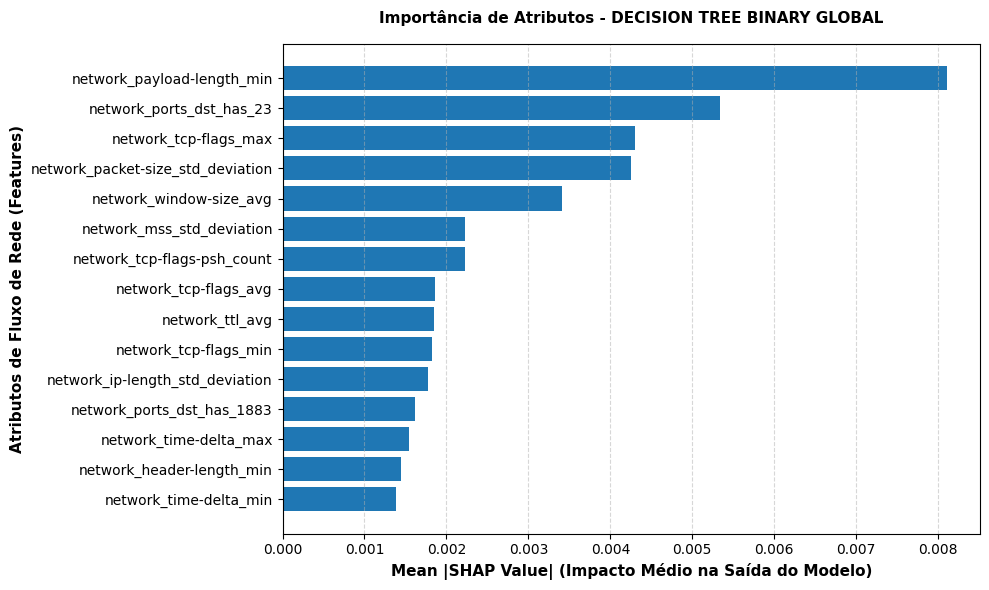

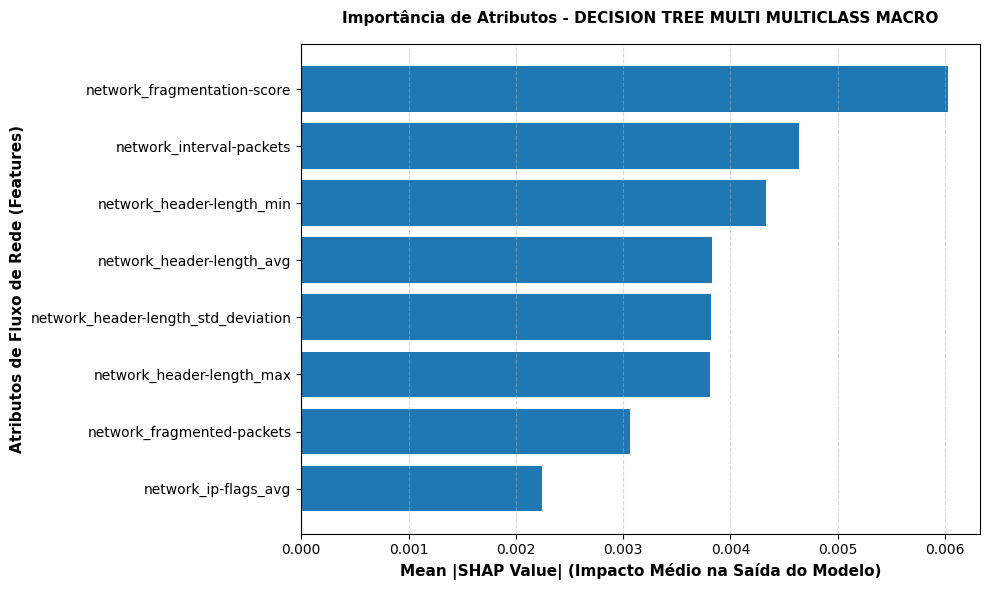

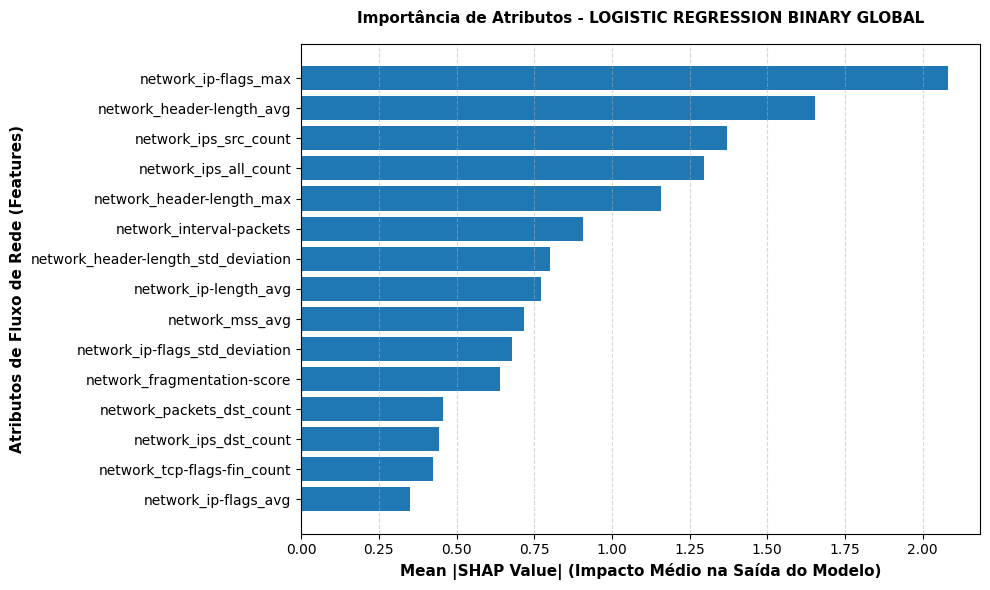

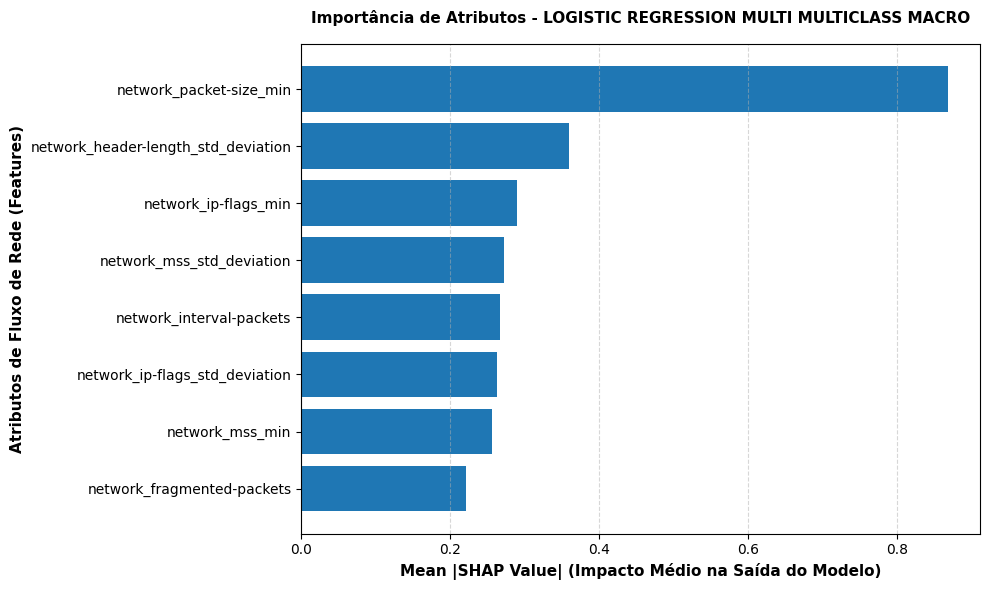

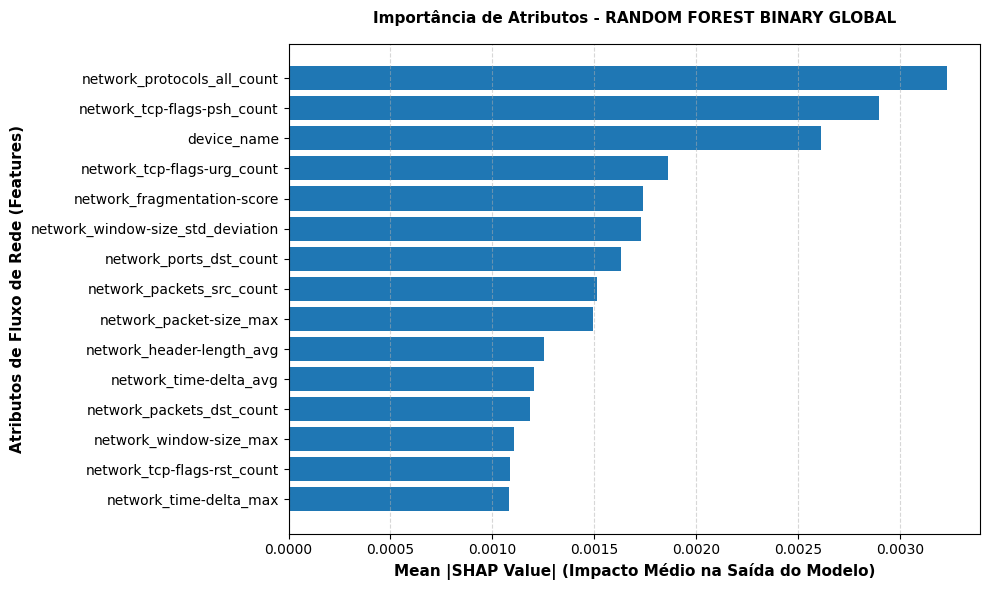

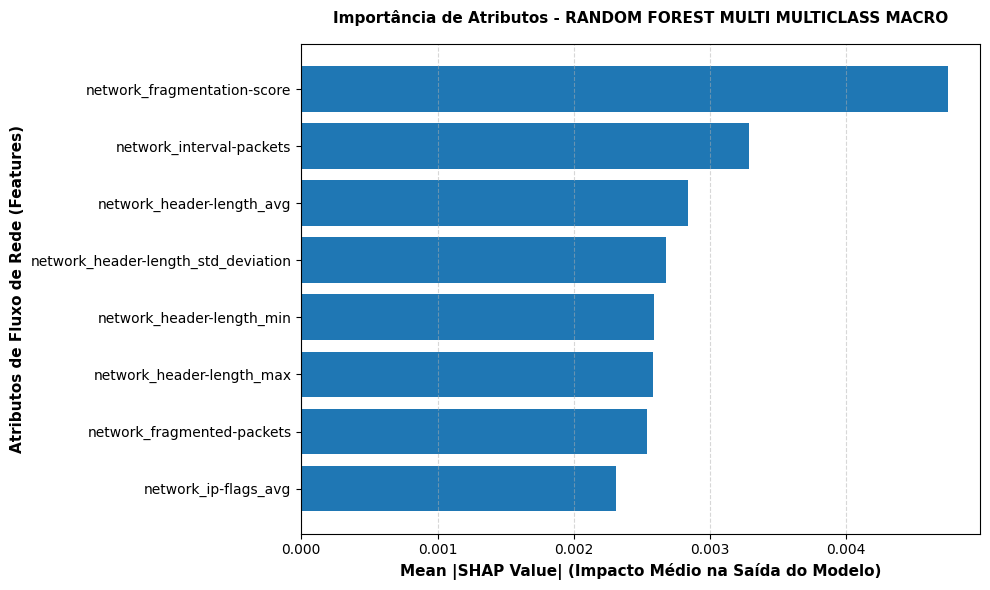

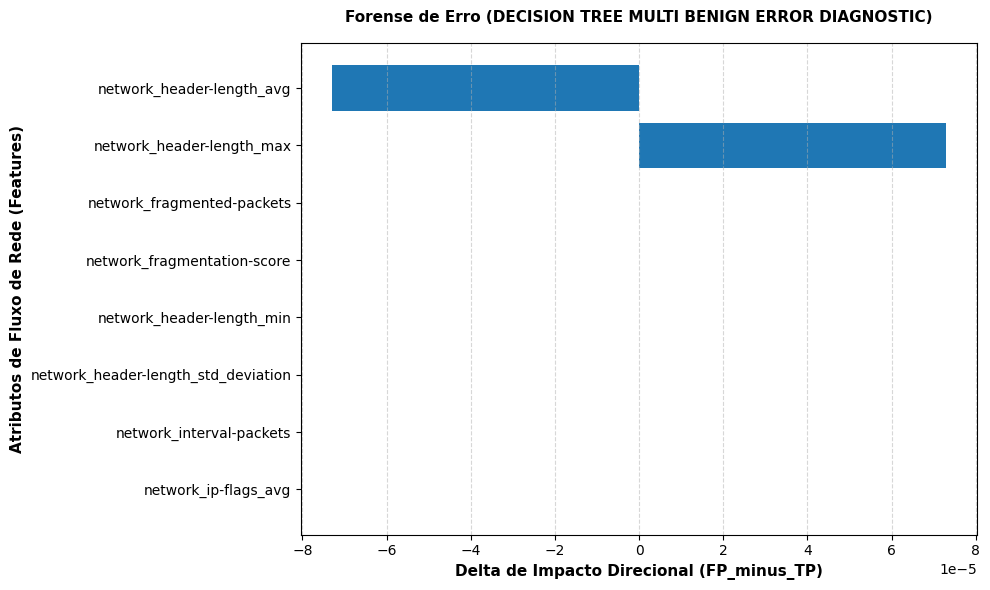

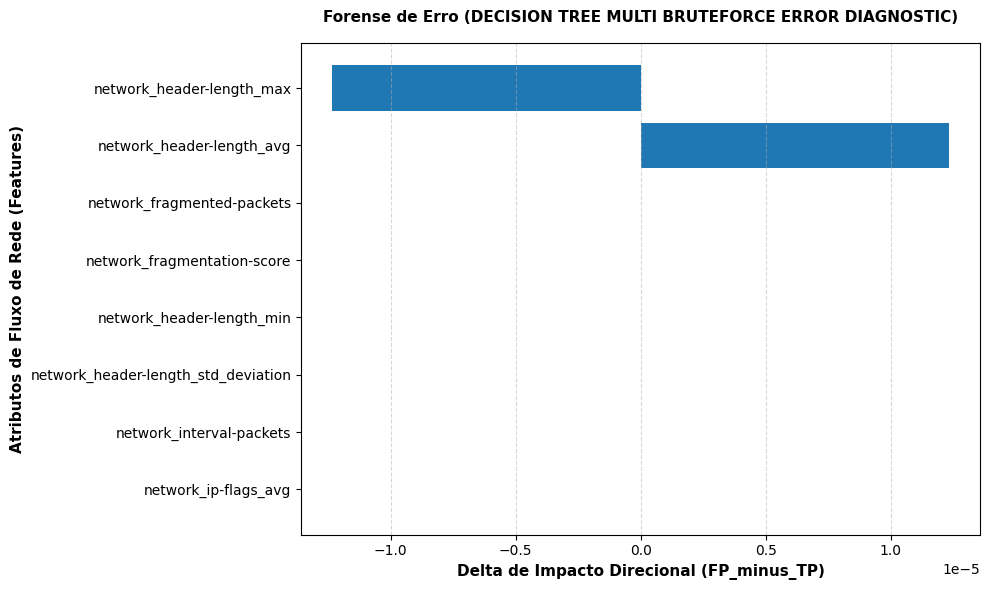

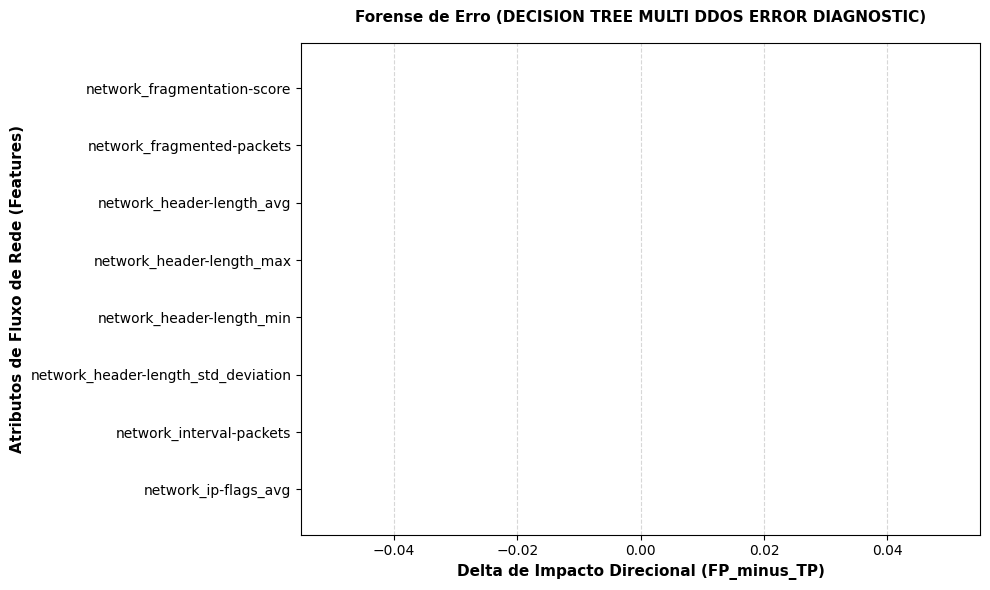

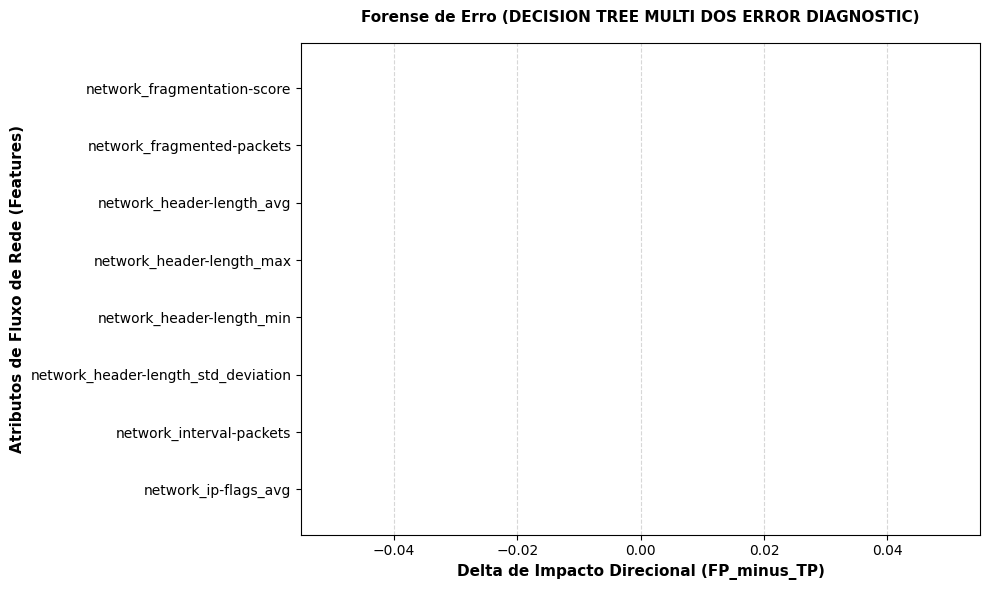

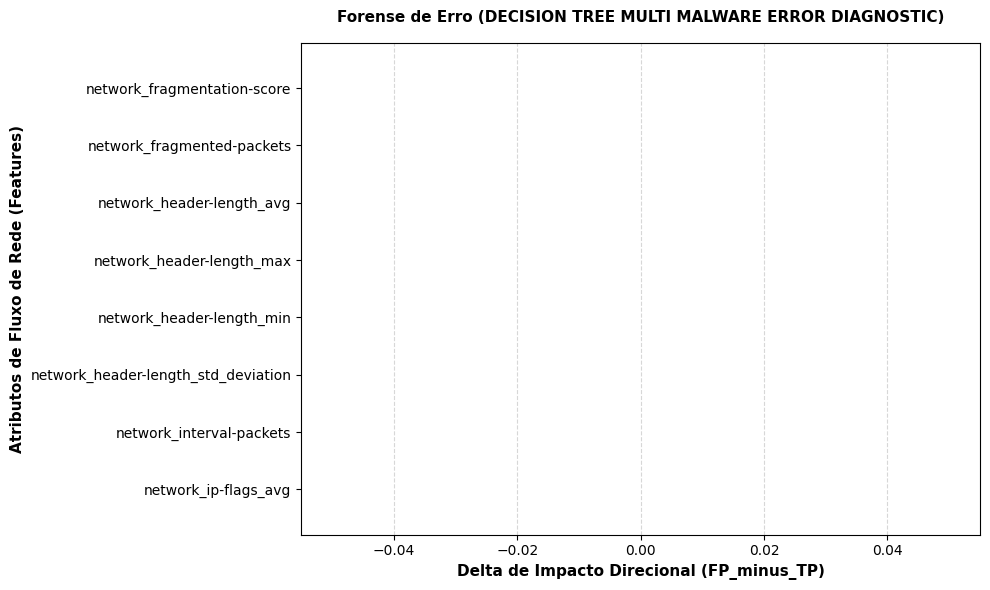

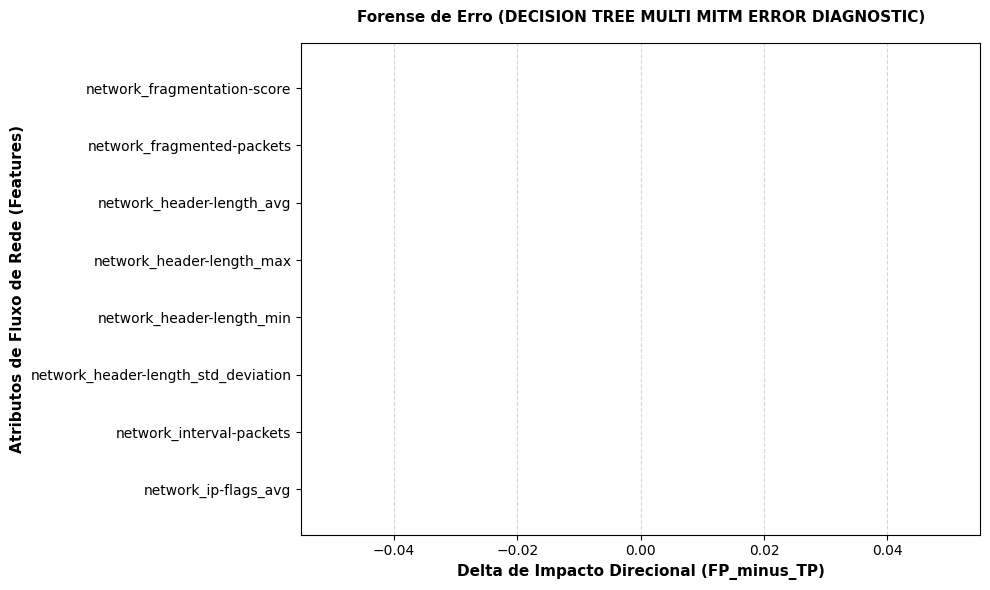

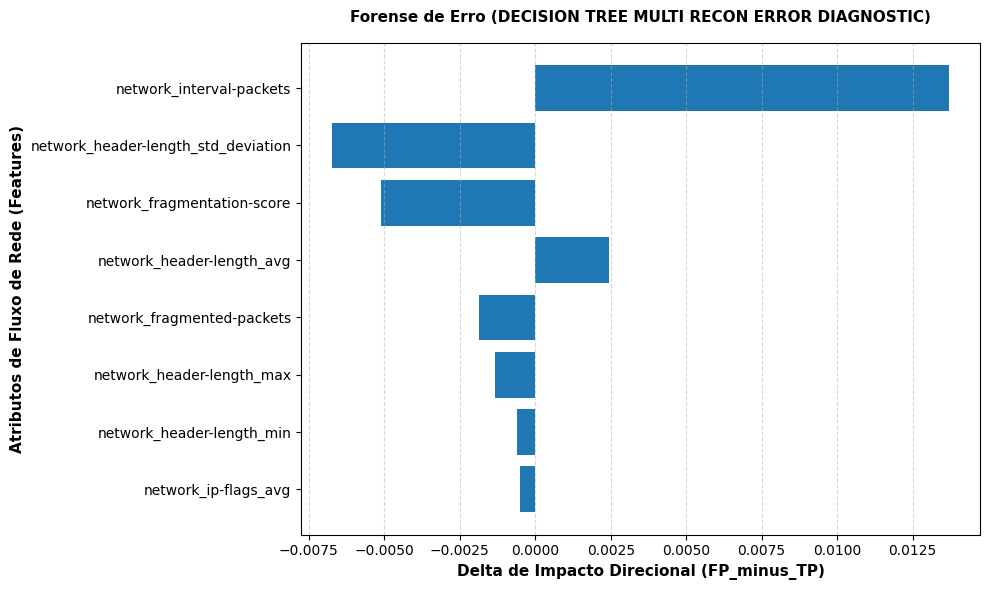

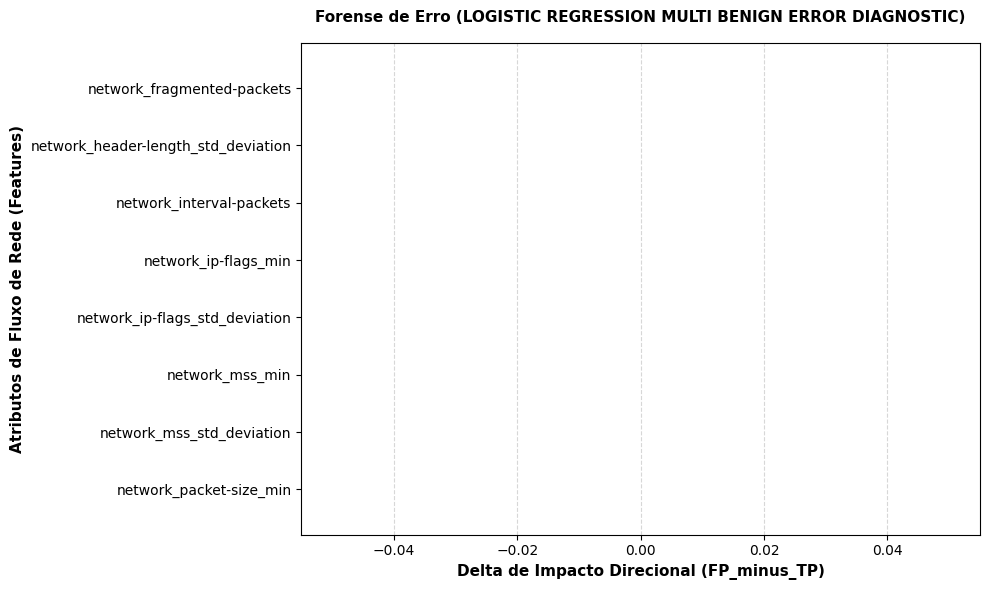

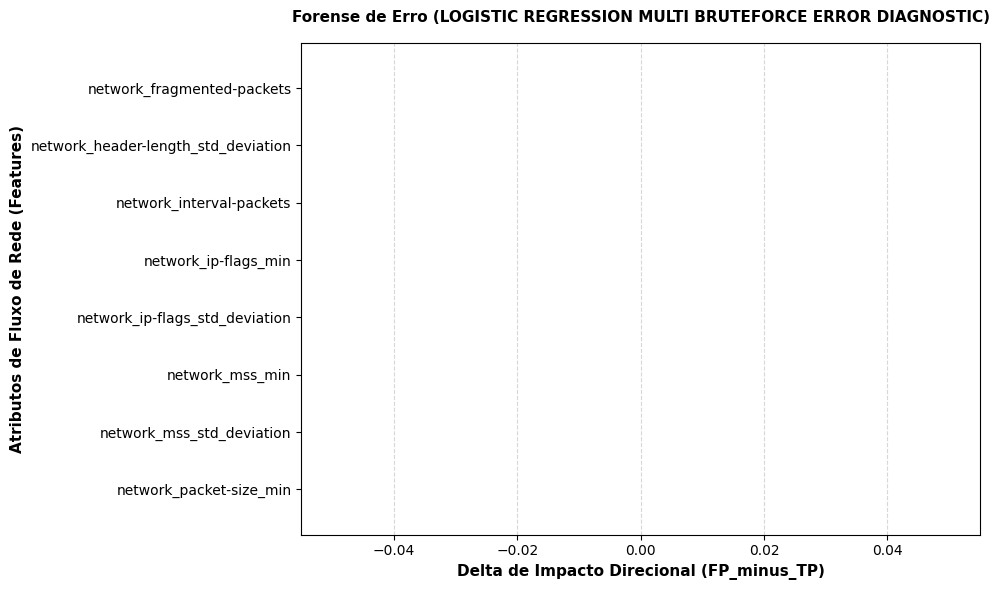

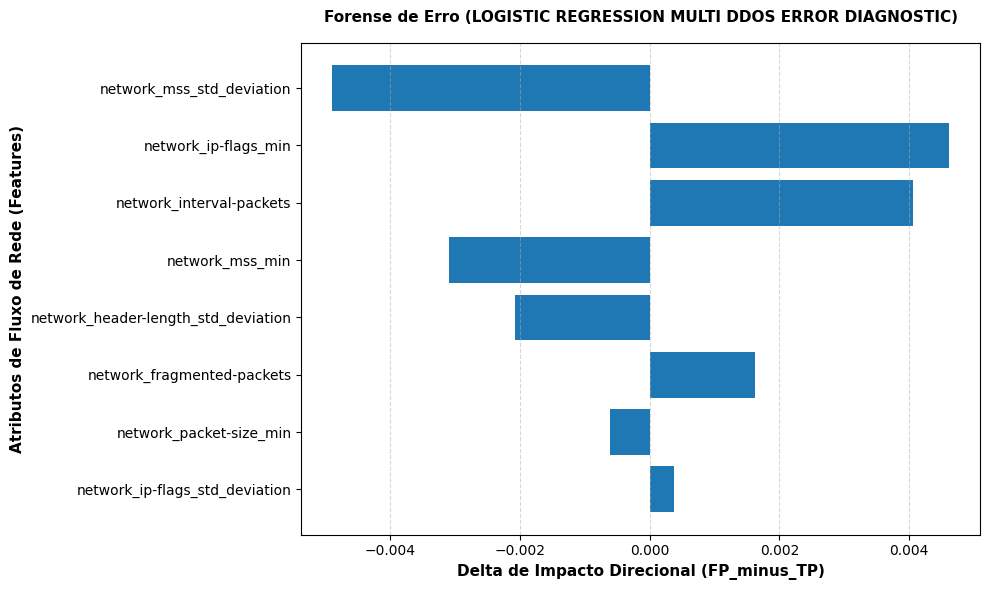

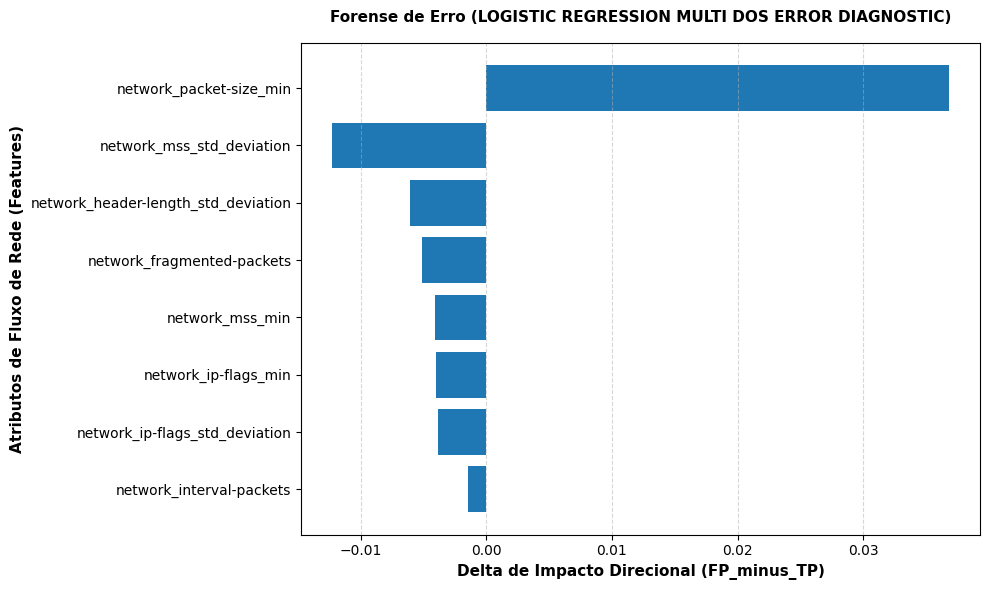

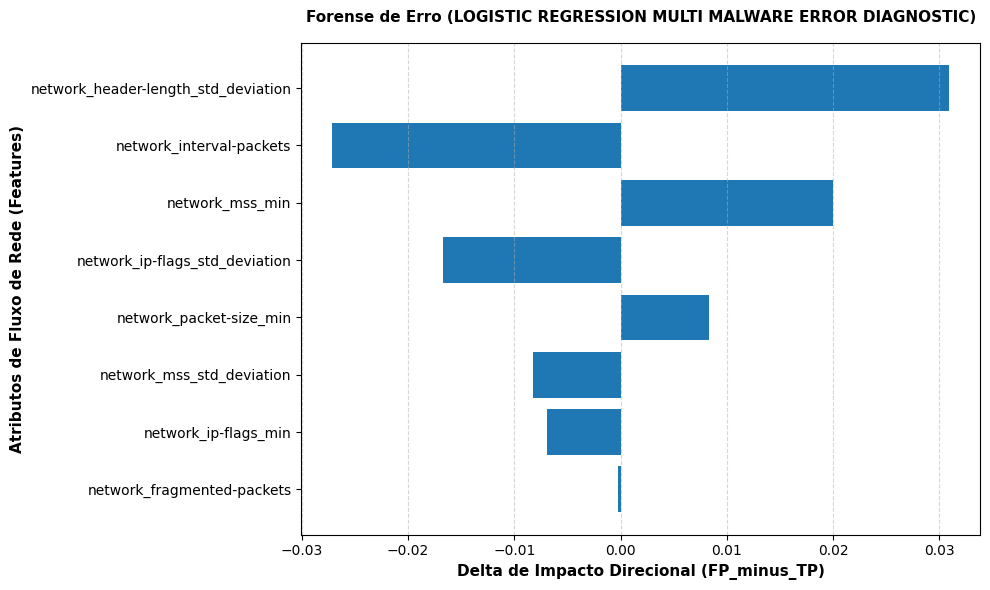

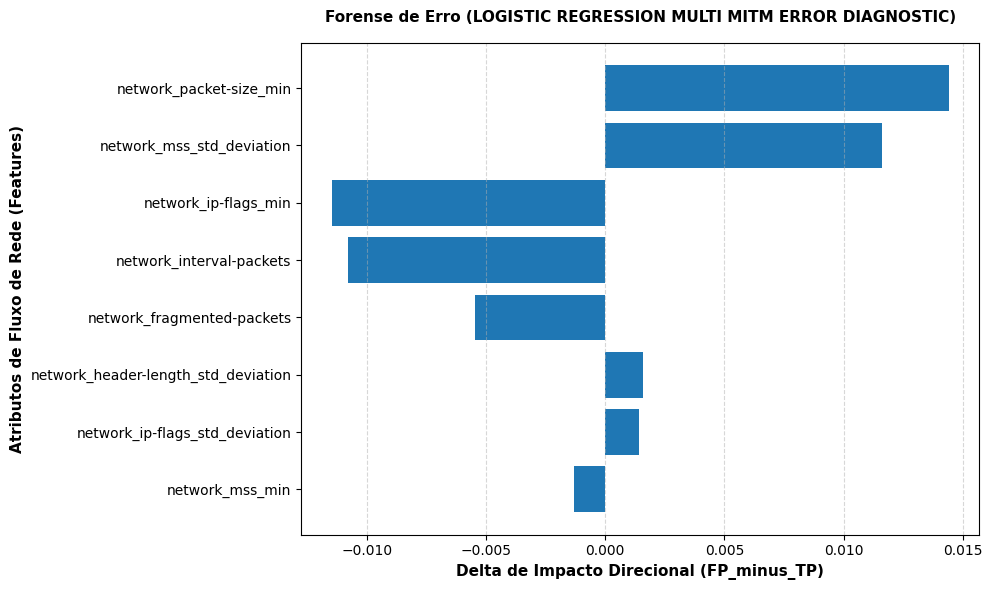

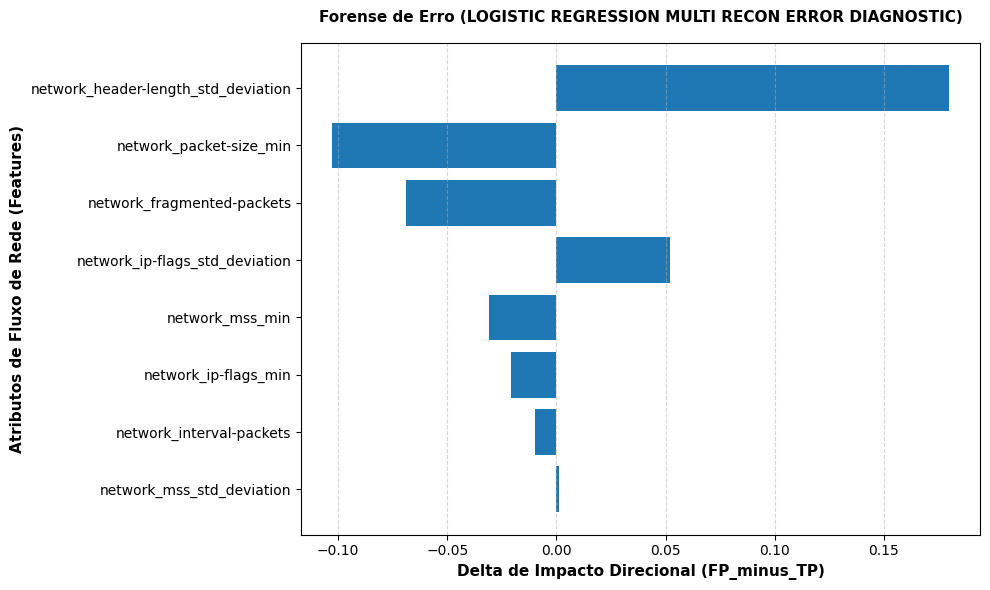

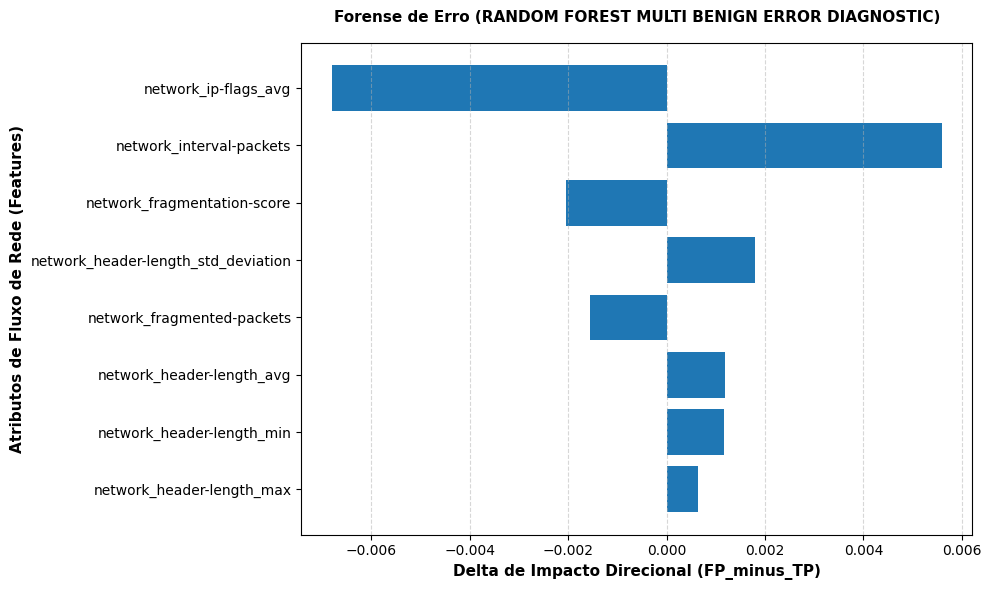

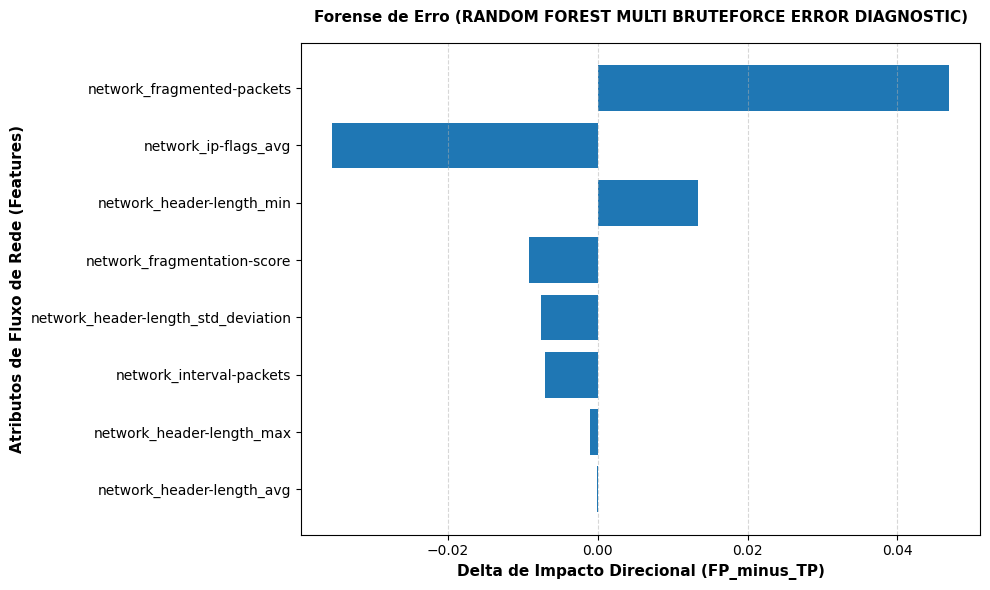

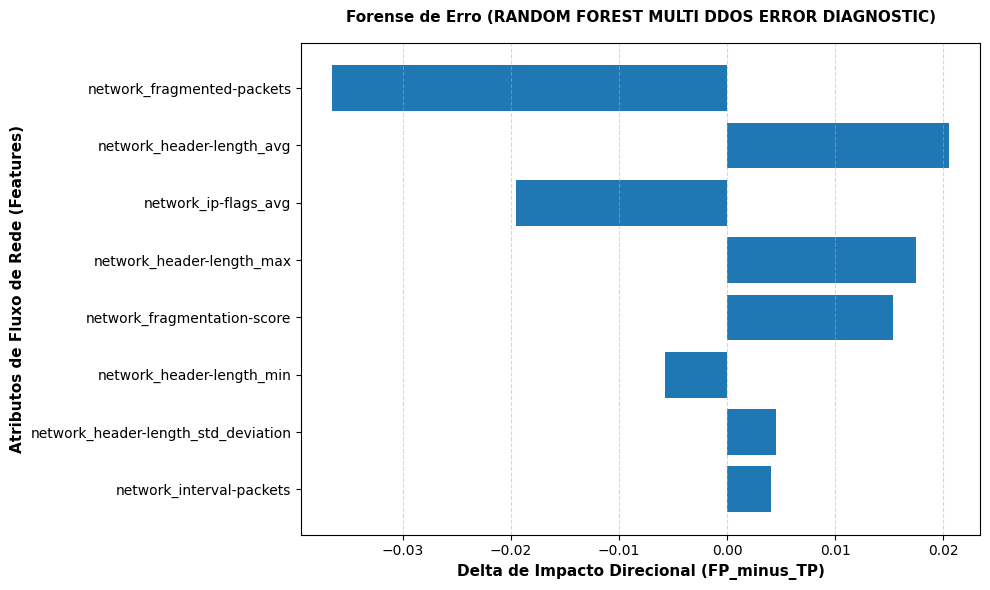

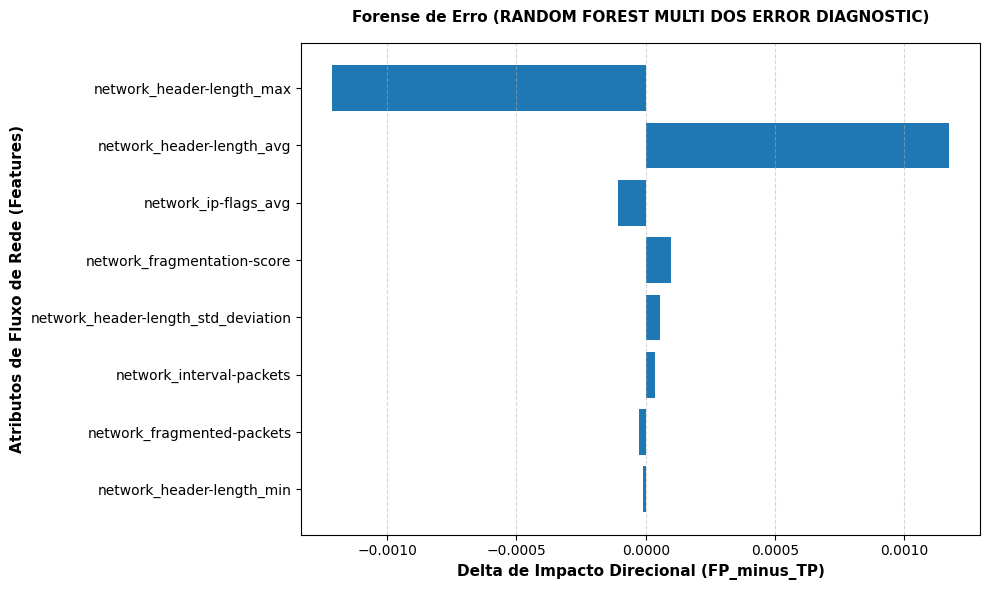

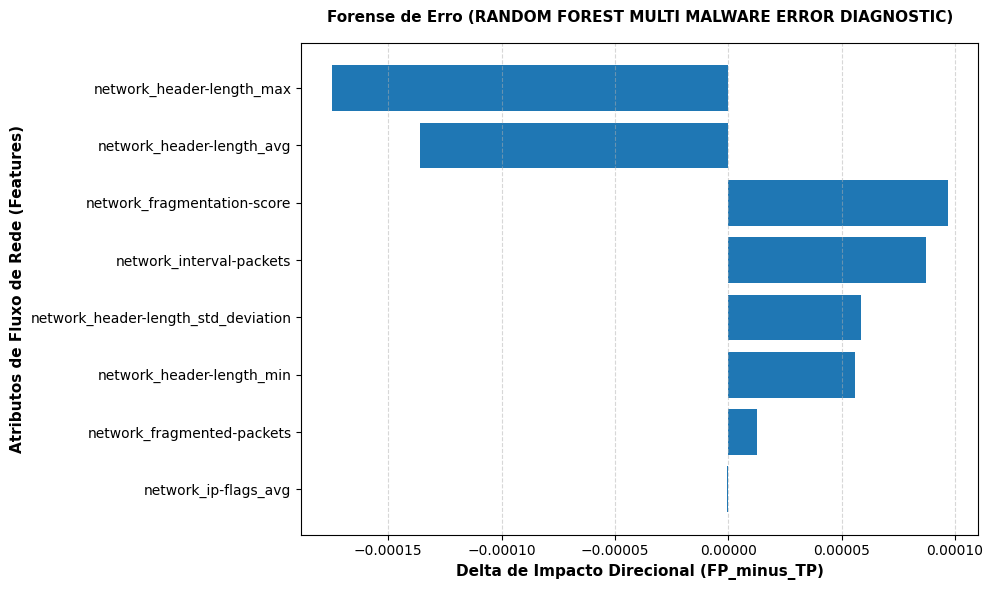

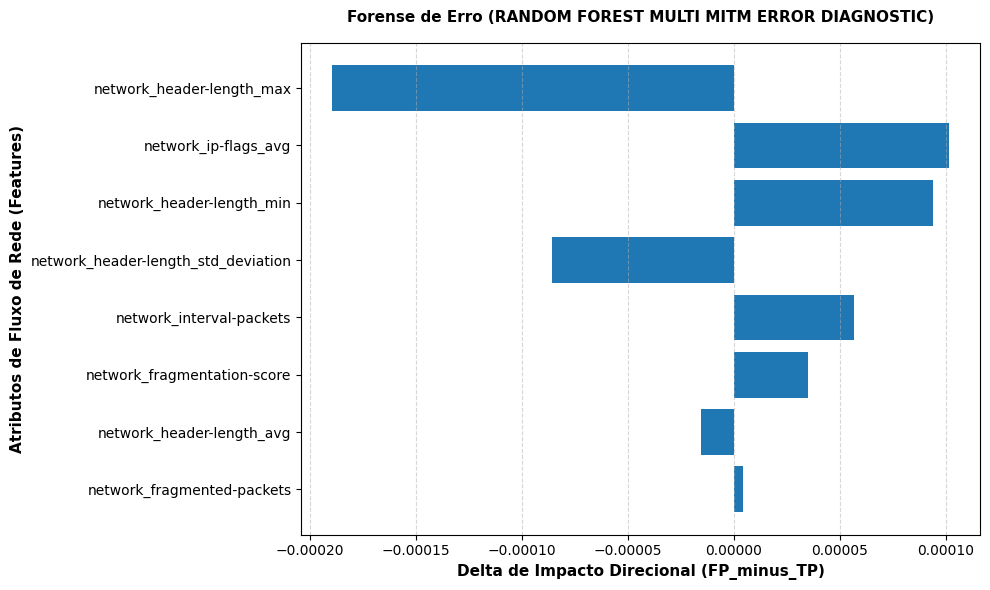

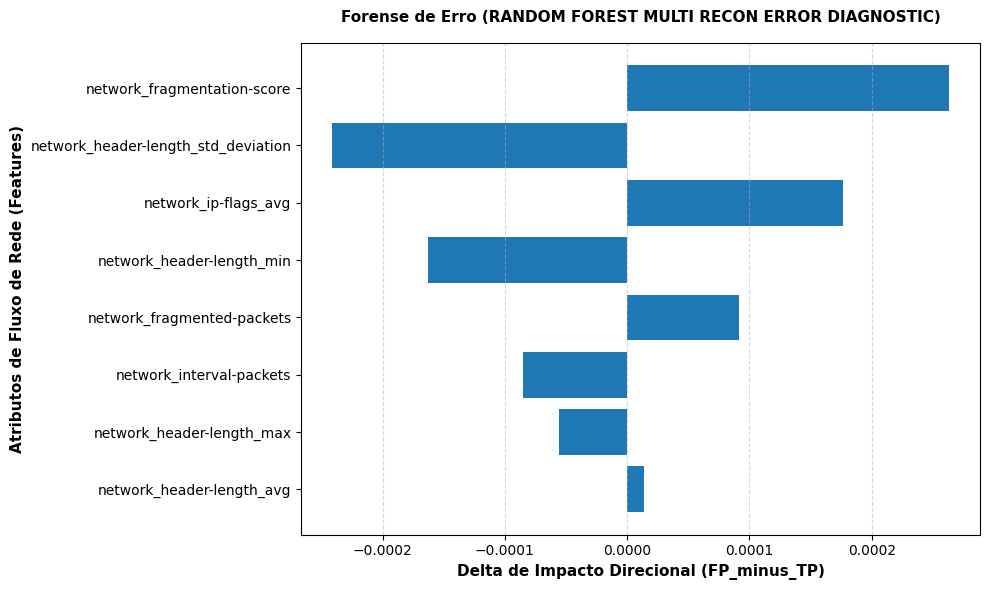


[SUCESSO] Rotina finalizada. 27 gráficos gerados/atualizados em: c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\experiments\results_xai\figures


In [2]:
print("[ROTINA VISUAL] Verificando diretórios e processando arquivos para o artigo...")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Garante a reconstrução dos caminhos caso o Kernel tenha sido reiniciado
PROJECT_ROOT = Path.cwd().parent
XAI_DIR = PROJECT_ROOT / "experiments" / "results_xai"
SHAP_GLOBAL_DIR = XAI_DIR / "shap_global"
FPFN_MULTI_DIR = XAI_DIR / "fpfn_multiclass"
FIG_DIR = XAI_DIR / "figures"

# Lista de pastas que contêm arquivos CSV que devem virar gráficos no artigo
pastas_alvo = [SHAP_GLOBAL_DIR, FPFN_MULTI_DIR]
TOP_N = 15
graficos_gerados = 0

for pasta in pastas_alvo:
    if not pasta.exists():
        continue
        
    for csv_file_path in pasta.glob("*.csv"):
        # Ignora arquivos de sumário que não possuem estrutura de features para plotagem
        if "summary" in csv_file_path.stem:
            continue
            
        chart_data_df = pd.read_csv(csv_file_path)
        
        # Identifica dinamicamente a coluna de métrica do CSV (suporta SHAP e as novas tabelas FPFN)
        colunas_disponiveis = chart_data_df.columns
        target_importance_col = None
        
        for col in ["importance_macro", "importance", "FP_minus_TP", "FN_minus_TP"]:
            if col in colunas_disponiveis:
                target_importance_col = col
                break
        
        # Se encontrou uma coluna válida, gera o gráfico ordenado pelo maior impacto absoluto
        if target_importance_col and "feature" in colunas_disponiveis:
            # Para o caso de FP e FN, queremos ver o maior impacto (independente de ser + ou - no desvio)
            chart_data_df["abs_sort"] = chart_data_df[target_importance_col].abs()
            top_plot_df = chart_data_df.sort_values("abs_sort", ascending=False).head(TOP_N)
            
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # Plota as barras invertidas para que a maior feature fique no topo do gráfico horizontal
            ax.barh(
                top_plot_df["feature"].iloc[::-1], 
                top_plot_df[target_importance_col].iloc[::-1], 
                color="#1f77b4", 
                edgecolor="none"
            )
            
            # Ajuste dinâmico dos labels dos eixos com base no tipo de análise forense
            if "minus" in target_importance_col:
                label_x = f"Delta de Impacto Direcional ({target_importance_col})"
                titulo = f"Forense de Erro ({csv_file_path.stem.replace('_', ' ').upper()})"
            else:
                label_x = "Mean |SHAP Value| (Impacto Médio na Saída do Modelo)"
                titulo = f"Importância de Atributos - {csv_file_path.stem.replace('_', ' ').upper()}"
            
            ax.set_xlabel(label_x, fontsize=11, fontweight="bold")
            ax.set_ylabel("Atributos de Fluxo de Rede (Features)", fontsize=11, fontweight="bold")
            ax.set_title(titulo, fontsize=11, fontweight="bold", pad=15)
            ax.grid(axis="x", linestyle="--", alpha=0.5)
            
            plt.tight_layout()
            
            # Salva a figura com alta resolução (300 DPI) para submissão científica
            nome_saida = f"plot_{pasta.name}_{csv_file_path.stem}.png"
            plt.savefig(FIG_DIR / nome_saida, dpi=300, bbox_inches="tight")
            plt.show()
            plt.close()
            graficos_gerados += 1

print(f"\n[SUCESSO] Rotina finalizada. {graficos_gerados} gráficos gerados/atualizados em: {FIG_DIR}")